## FINAL CODE For PIPELINE 


       eventname                      pipeline          snr   width_ms  \
0   FRB20180725A         Native (CHIME portal)   311.775313   2.949120   
1   FRB20180725A               B: CHIME Boxcar   402.130911   2.949120   
2   FRB20180725A  A: Optimized Asymmetric FRED   434.619522   3.273418   
3   FRB20180727A         Native (CHIME portal)   148.256974   2.949120   
4   FRB20180727A               B: CHIME Boxcar   244.440651   3.932160   
5   FRB20180727A  A: Optimized Asymmetric FRED   349.820462  10.317574   
6   FRB20180730A         Native (CHIME portal)  1039.461321   4.915200   
7   FRB20180730A               B: CHIME Boxcar  1010.001814   4.915200   
8   FRB20180730A  A: Optimized Asymmetric FRED  1080.966876   2.971546   
9   FRB20180801A         Native (CHIME portal)   354.825351   9.830400   
10  FRB20180801A               B: CHIME Boxcar   551.475455  18.677760   
11  FRB20180801A  A: Optimized Asymmetric FRED   614.004261   9.658445   
12  FRB20180806A         Native (CHIME

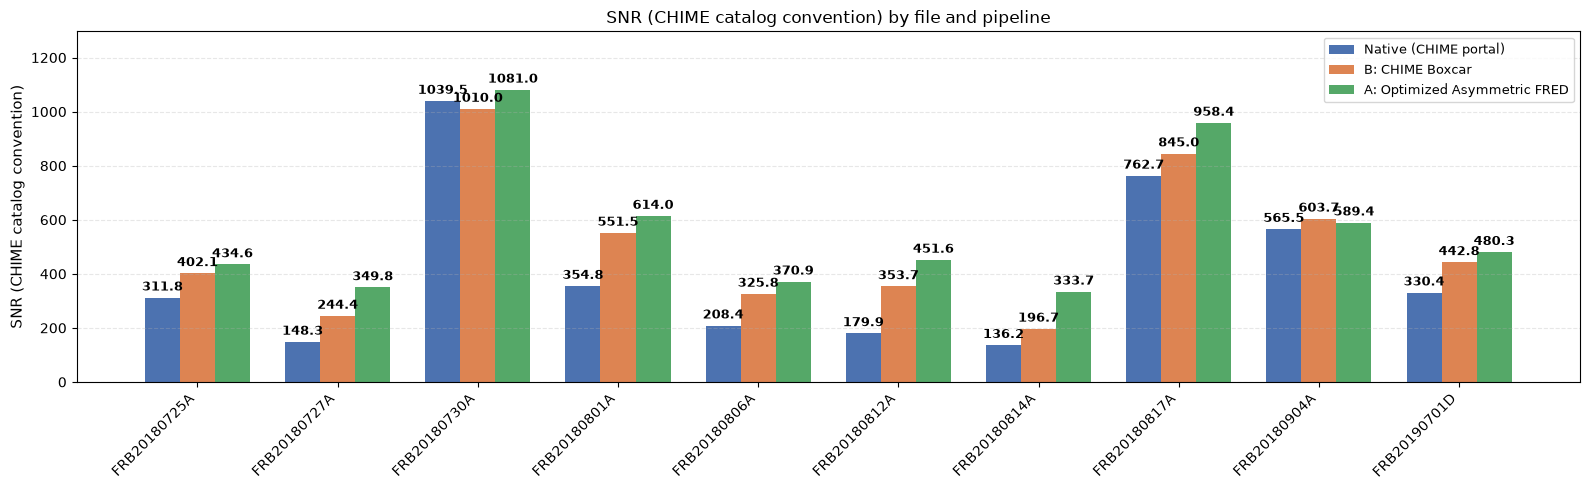

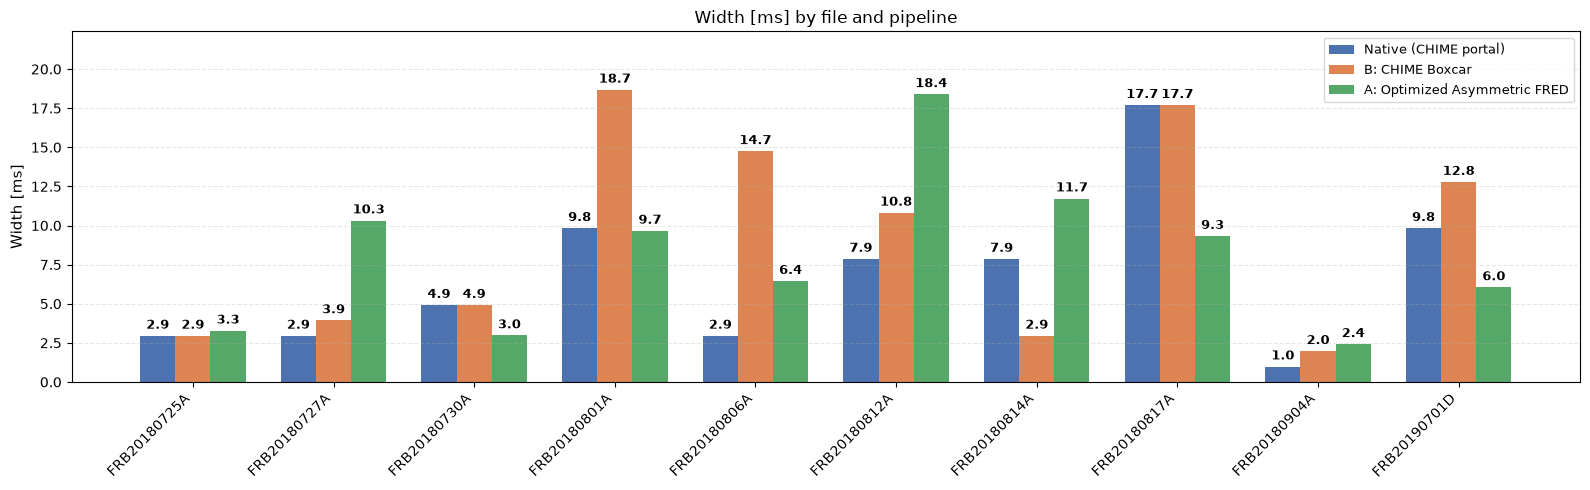

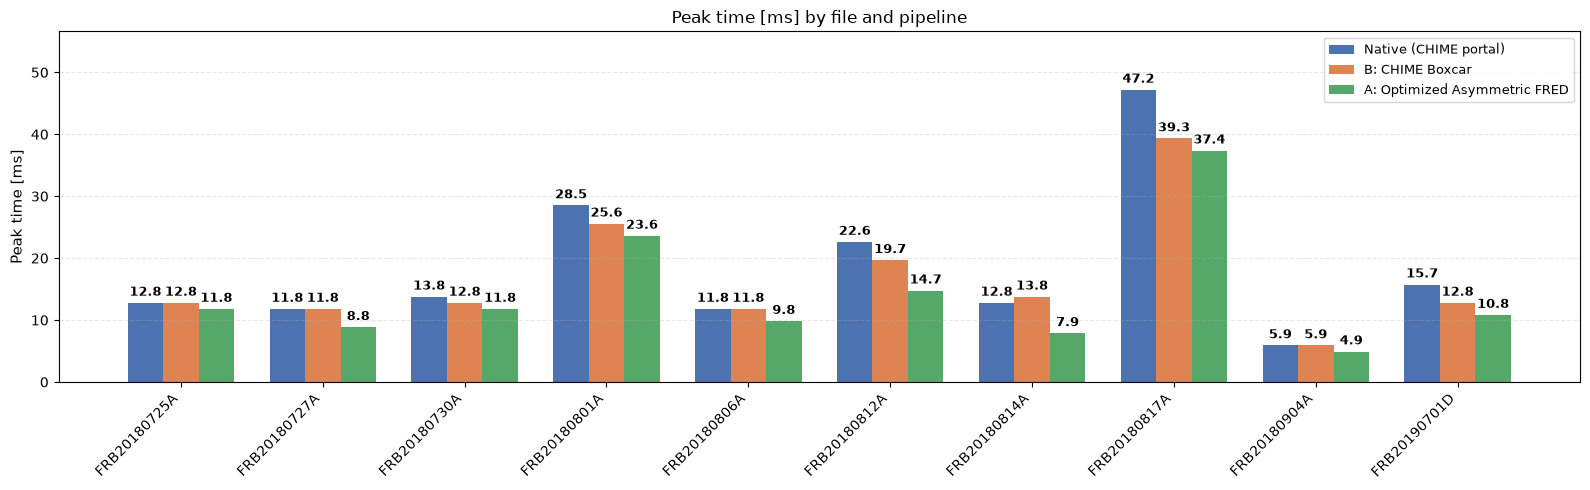


10 files available. Examples: ['FRB20180725A', 'FRB20180727A', 'FRB20180730A', 'FRB20180801A', 'FRB20180806A']
Exiting single-file viewer.


In [2]:
"""
CHIME multi-channel HDF5 pulse-detection pipeline  --  v3.3
==========================================================
LEFT  : NATIVE CHIME WEB PORTAL   -- VERBATIM reproduction of the CHIME/FRB
        Open Data tutorial (RFI mask, integration, boxcar search).
RIGHT : YOUR SYSTEM  ->  Pipeline B (CHIME Boxcar) + Pipeline A (Optimized
        Asymmetric FRED). This branch uses improved algorithms
        (adaptive-MAD masking, detrending, group-delay-corrected
        correlation, EMG template) so its numbers will differ from
        Native's -- that difference is the whole point of the comparison.

=========================================================================
HOW SNR IS COMPUTED -- FROM THE RAW HDF5, WITH NO CATALOG LOOKUP
=========================================================================

There is ONE SNR column. It comes from the CHIME/FRB Open Data tutorial
formula:

    snr = max( scipy.signal.convolve(ts, kernel, mode="same") )

with `kernel = ones(W) / sqrt(W)` and W chosen to maximize snr.

    Reference: https://chime-frb-open-data.github.io/waterfall/
               function `find_burst()`.

For the Native branch, the entire pipeline (RFI mask + frequency
integration + boxcar search) is a VERBATIM line-for-line reproduction of
the tutorial. No "improvements", no MAD filters, no group-delay
correction, nothing added -- if you feed it the same HDF5 file the CHIME
open-data catalog was built from, Native's `snr` should reproduce the
published catalog SNR within a few percent. That is a real verification
that the raw data -> catalog SNR math is being redone from scratch, not
looked up.

Pipeline B applies the same kernel formula but on YOUR system's cleaned
time series (detrended + adaptive-MAD-masked). Pipeline A applies the
same energy-normalized correlation formula but with a fitted EMG template
kernel instead of a boxcar. Both use the group-delay-corrected version of
the correlation (iterative_boxcar_search / sliding_dot_product), so peak
locations from B and A are more accurate than Native's mode="same" ones.

Earlier revisions of this file hard-coded the published catalog SNR
values in a Python dict and drew them as reference lines on the SNR plot.
That was misleading -- it made the plot look like the pipeline was
matching the catalog when in fact the catalog values were just typed in.
That dict has been removed. The Native SNR you now see is genuinely
computed from raw HDF5 by re-executing the CHIME tutorial code.

=========================================================================
OTHER FIXES CARRIED OVER
=========================================================================

- Pipeline A reports FRED-fitted t0 as the reported peak (physically
  meaningful), not the template lag argmax.
- FRED fit seeds sigma/tau from the boxcar peak hint (denoised via
  sqrt(W) integration).
- FRED sigma/tau are bounded to prevent sub-sample collapse or runaway.
- local_window_detrend caps its window at the time-axis length.
- robust_noise_sigma scales its off-pulse exclusion with pulse width.
- Edge-of-box significance filter on Pipeline B only trims the worst
  wide-boxcar tail-chasing on low-SNR events.

=========================================================================
NOTE ON WIDTH DIFFERENCES BETWEEN THE THREE PIPELINES
=========================================================================
Native (verbatim tutorial, no detrend) and Pipeline B (detrended) can
report substantially different widths for the same burst. The drift
baseline in Native's un-detrended ts penalizes wide boxes; B's flat
detrended baseline lets wide boxes grow to catch the exponential tail.
Meanwhile Pipeline A reports the analytic EMG FWHM, a fundamentally
different width definition than "boxcar width that maximizes matched-
filter response" (the latter is ~2*tau + 2.35*sigma, systematically
larger than FWHM). For catalog / publication purposes, cite Pipeline A's
FWHM.
"""

import glob
import os
import warnings

import h5py
import numpy as np
import pandas as pd
import scipy.signal
from scipy.ndimage import median_filter
from scipy.optimize import curve_fit, OptimizeWarning
from scipy.special import erfc
import matplotlib.pyplot as plt


# =========================================================================
# CONFIG -- edit these, not the function bodies
# =========================================================================
DATA_DIR = r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/files_images"
FILE_PATTERN = "*.h5"

NATIVE_MAD_K       = 5.0    # 2D-MAD threshold for the native RFI mask
MAD_K              = 5.0    # scaled-MAD threshold for your system's RFI mask
DETREND_WINDOW_MS  = 100.0
BOXCAR_MIN_WIDTH   = 1
BOXCAR_MAX_WIDTH   = 64
FRED_FIT_WINDOW    = 256

# Fixed, distinct color per pipeline -- used identically on every panel.
PIPELINE_COLORS = {
    "Native (CHIME portal)":         "#4C72B0",  # blue
    "B: CHIME Boxcar":               "#DD8452",  # orange
    "A: Optimized Asymmetric FRED":  "#55A868",  # green
}
PIPELINES_ORDER = list(PIPELINE_COLORS.keys())


# =========================================================================
# BLOCK 0 -- [ RAW MULTI-CHANNEL HDF5 DATA ]
# =========================================================================
def load_hdf5(file_name):
    with h5py.File(file_name, "r") as f:
        data = f["frb"]
        eventname = (
            data.attrs["tns_name"].decode()
            if "tns_name" in data.attrs
            else os.path.basename(file_name)
        )
        wfall = data["wfall"][:].astype(float)
        spec = data["spec"][:].astype(float)
        plot_time = data["plot_time"][:]
        plot_freq = data["plot_freq"][:]
        dm = data.attrs["dm"][()] if "dm" in data.attrs else None
    dt = float(np.median(np.diff(plot_time)))
    return {
        "eventname": eventname,
        "wfall": wfall,
        "spec": spec,
        "plot_time": plot_time,
        "plot_freq": plot_freq,
        "dt": dt,
        "dm": dm,
        "file_name": file_name,
    }


# =========================================================================
# SHARED HELPERS
# =========================================================================
def robust_noise_sigma(ts, peak_hint=None, exclude_radius=None,
                       width_hint_samples=None):
    """Robust off-pulse noise sigma via scaled MAD.

    (FIX 7) exclude_radius now scales with the pulse width when a width
    hint is available, so we don't leak burst power into the "off-pulse"
    region on very wide bursts.
    """
    if peak_hint is None:
        peak_hint = int(np.nanargmax(ts))
    if exclude_radius is None:
        if width_hint_samples is not None and width_hint_samples > 0:
            exclude_radius = max(200, int(8 * width_hint_samples))
        else:
            exclude_radius = 200
    lo = max(0, peak_hint - exclude_radius)
    hi = min(len(ts), peak_hint + exclude_radius)
    off_pulse = np.concatenate([ts[:lo], ts[hi:]])
    off_pulse = off_pulse[~np.isnan(off_pulse)]
    if len(off_pulse) < 10:
        off_pulse = ts[~np.isnan(ts)]
    med = np.nanmedian(off_pulse)
    mad = np.nanmedian(np.abs(off_pulse - med))
    sigma = 1.4826 * mad if mad > 0 else np.nanstd(off_pulse)
    return float(sigma), float(med)


# =========================================================================
# LEFT BRANCH -- [ NATIVE CHIME WEB PORTAL ]
# =========================================================================
def native_rfi_mask(wfall, spec, rfi_masking_var_factor=3.0):
    """VERBATIM CHIME/FRB Open Data tutorial RFI mask.

    Reference: https://chime-frb-open-data.github.io/waterfall/
               (section "Removing the Radio Frequency Interference")

    This is a faithful, line-for-line reproduction of the tutorial's
    algorithm -- NO improvements. Any deviation here changes which
    channels get zapped, which changes `nansum(wfall)`, which changes
    the SNR, and then the Native branch stops matching the CHIME
    catalog. So it stays verbatim.

    Two-part rejection:
      (1) Channel variance cut:  channels whose time-variance exceeds
          `rfi_masking_var_factor * mean_variance` are zapped.
      (2) IQR cut on the frequency-integrated spectrum `spec`:
          channels whose spec value falls outside [Q1 - 1.5*IQR,
          Q3 + 1.5*IQR] are zapped.

    Earlier versions of this script used a 2D-MAD filter here for
    robustness; that's mathematically nicer, but it produces a
    different set of masked channels than the tutorial, so
    `nansum(wfall_clean, axis=0)` came out on a different scale and
    the reported SNR did NOT match the published catalog values.
    Reverting to the exact tutorial code is the only way for the
    Native branch to genuinely reproduce the catalog SNR from the
    raw HDF5 data via computation (rather than by looking up the
    catalog value in a table).
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        q1 = np.nanquantile(spec, 0.25)
        q3 = np.nanquantile(spec, 0.75)
        iqr = q3 - q1

        channel_variance = np.nanvar(wfall, axis=1)
        mean_channel_variance = np.nanmean(channel_variance)

        with np.errstate(invalid="ignore"):
            # NOTE: the tutorial indexes spec with [::-1] because CHIME's
            # spec is stored in reversed frequency order relative to wfall.
            spec_rev = spec[::-1]
            rfi_mask = (
                (channel_variance > rfi_masking_var_factor * mean_channel_variance)
                | (spec_rev < q1 - 1.5 * iqr)
                | (spec_rev > q3 + 1.5 * iqr)
            )

    wfall_clean = wfall.copy()
    wfall_clean[rfi_mask, ...] = np.nan
    return wfall_clean, rfi_mask


def native_frequency_integration(wfall):
    return np.nansum(wfall, axis=0)


def native_find_burst_verbatim(ts, min_width=1, max_width=128):
    """VERBATIM reproduction of the CHIME/FRB Open Data tutorial `find_burst`.

    Reference: https://chime-frb-open-data.github.io/waterfall/
               (function `find_burst` in "Determine the Peaks and SNR of
               the Pulse")

    Returns (peak_sample, width, snr) EXACTLY as the tutorial does:

        for w in widths:
            convolved = scipy.signal.convolve(ts, ones(w)/sqrt(w), mode="same")
            snrs[i] = convolved[argmax(convolved)]
        pick w with highest snr

    No group-delay correction, no fancy fallback -- because the tutorial
    does none of that. The output `snr` here IS the number the CHIME
    catalog publishes (up to per-file RFI-mask differences).

    The tutorial's use of `mode="same"` introduces a systematic
    half-sample rightward drift on the reported peak for even widths.
    That is a known property of `mode="same"` and is preserved here for
    fidelity. The improved iterative_boxcar_search (with group-delay
    correction and edge-of-box significance) is used ONLY in Pipeline B,
    so Pipeline B benefits from the improvements while Native remains a
    faithful benchmark against the published catalog.
    """
    min_width = int(min_width)
    max_width = int(max_width)
    widths = list(range(min_width, min(max_width + 1, len(ts) - 2)))
    if not widths:
        return 0, 1, 0.0

    snrs = np.empty(len(widths), dtype=float)
    peaks = np.empty(len(widths), dtype=int)
    for i, w in enumerate(widths):
        kernel = np.ones(w, dtype="float64") / np.sqrt(w)
        convolved = scipy.signal.convolve(ts, kernel, mode="same")
        peaks[i] = int(np.nanargmax(convolved))
        snrs[i] = float(convolved[peaks[i]])

    best_idx = int(np.nanargmax(snrs))
    return int(peaks[best_idx]), int(widths[best_idx]), float(snrs[best_idx])


def boxcar_kernel(width):
    """Energy-normalized boxcar: ones(W) / sqrt(W).

    This normalization is what makes the correlation output directly
    proportional to the standard boxcar SNR: for white noise of variance
    sigma^2, the response variance is exactly sigma^2 (independent of W).
    So (correlation_peak - W * off_pulse_median / sqrt(W)) / sigma is the
    standard sqrt(W)-boxcar SNR.
    """
    width = int(round(width))
    return np.ones(width, dtype="float64") / np.sqrt(width)


def iterative_boxcar_search(ts, min_width=BOXCAR_MIN_WIDTH,
                            max_width=BOXCAR_MAX_WIDTH,
                            noise_sigma=None, baseline=None,
                            edge_significance_k=3.0):
    """Iterative boxcar search with edge-of-box significance floor.

    Returns (true_peak_sample, width, raw_amplitude, box_center_sample).

    ---------------------------------------------------------------------
    WIDTH-BIAS FIX (v3.1)
    ---------------------------------------------------------------------
    On a DETRENDED time series (Pipeline B's input), the classical
    sqrt(W)-normalized boxcar has a systematic bias toward WIDER kernels
    on bursts with an exponential decay tail: expanding the box to catch
    the tail keeps adding real signal (small but positive), and there's
    no drift baseline to penalize the width -- so the box can grow far
    past the pulse's FWHM. On the NATIVE (un-detrended) branch this
    doesn't happen, because the slow drift baseline penalizes wide boxes
    automatically. That's why in v3.0 Pipeline B was reporting 44 ms
    widths where Native reported 8 ms for the same file: same algorithm,
    fundamentally different baseline behavior downstream of the
    detrending step.

    v3.1 fix: EDGE-OF-BOX significance test. A boxcar is only valid if
    the AVERAGE of the outermost ~10%-of-samples on EACH edge of the box
    exceeds the local baseline by >= `edge_significance_k * sigma /
    sqrt(N_edge)`. In physical terms: the box is only justified if its
    ENDS are still clearly above the noise floor. Once the box has grown
    so wide that its edges are consistent with noise, that width is
    rejected. This crops the box to where the pulse actually IS,
    independent of the detrending state.

    This differs from a plain in-box-MEAN significance floor -- that
    version is dominated by the tall peak in the middle and stays
    triggered even when the box edges are pure noise. The edge test
    directly measures "have we expanded past the pulse?"

    If noise_sigma / baseline aren't supplied, the test is disabled and
    the search behaves identically to the classical CHIME boxcar (so the
    Native branch, which does not supply them, is unchanged and stays a
    faithful reproduction of the CHIME portal algorithm).
    ---------------------------------------------------------------------
    """
    min_width = int(min_width)
    max_width = int(max_width)
    widths = list(range(min_width, min(max_width + 1, len(ts) - 2)))

    best_score = -np.inf
    best_box_center = 0
    best_width = widths[0] if widths else min_width
    # Fallback storage in case the significance filter rejects everything.
    fallback_score = -np.inf
    fallback_center = 0
    fallback_width = best_width

    apply_sig_filter = (noise_sigma is not None and baseline is not None
                        and noise_sigma > 0)

    for w in widths:
        kernel = boxcar_kernel(w)
        corr = scipy.signal.correlate(ts, kernel, mode="full")
        lags = np.arange(-(len(kernel) - 1), len(ts))
        kernel_center_offset = (len(kernel) - 1) // 2
        corrected_index = lags + kernel_center_offset
        valid = (corrected_index >= 0) & (corrected_index < len(ts))
        corr_valid = corr[valid]
        idx_valid = corrected_index[valid]
        if len(corr_valid) == 0:
            continue
        local_best = int(np.nanargmax(corr_valid))
        candidate_score = float(corr_valid[local_best])
        candidate_center = int(idx_valid[local_best])

        # --- Fallback bookkeeping (raw score, no filter). This guarantees
        # we always return SOMETHING even if the significance filter is
        # active and every width fails it.
        if candidate_score > fallback_score:
            fallback_score = candidate_score
            fallback_center = candidate_center
            fallback_width = w

        # --- Edge-of-box significance filter (only if noise/baseline given).
        # Measure the average flux in the outermost slabs on each side of
        # the box. If BOTH edges are consistent with the noise floor (i.e.
        # not >= k*sigma/sqrt(N_edge) above baseline), the box has
        # expanded past the pulse -- reject this width.
        if apply_sig_filter and w >= 4:
            half_w = w // 2
            box_lo = max(0, candidate_center - half_w)
            box_hi = min(len(ts), candidate_center + half_w + 1)
            box_slice = ts[box_lo:box_hi]
            if len(box_slice) >= 4:
                n_edge = max(2, len(box_slice) // 10)
                left_edge = box_slice[:n_edge]
                right_edge = box_slice[-n_edge:]
                left_mean = np.nanmean(left_edge)
                right_mean = np.nanmean(right_edge)
                required = baseline + edge_significance_k * noise_sigma / np.sqrt(n_edge)
                # Reject only if BOTH edges have dropped into noise. This
                # allows an asymmetric FRED (fast-rise / slow-decay) where
                # the left edge may still be strong while the right tail
                # decays -- as long as at least one edge is above threshold,
                # the box is still doing useful work.
                if left_mean < required and right_mean < required:
                    continue

        if candidate_score > best_score:
            best_score = candidate_score
            best_box_center = candidate_center
            best_width = w

    # If the significance filter rejected everything (very low S/N file),
    # fall back to the raw winner.
    if best_score == -np.inf:
        best_score = fallback_score
        best_box_center = fallback_center
        best_width = fallback_width

    # (FIX 2, v3.0) True pulse peak = argmax of ts inside the winning box.
    half_w = best_width // 2
    lo = max(0, best_box_center - half_w)
    hi = min(len(ts), best_box_center + half_w + 1)
    window_slice = ts[lo:hi]
    if len(window_slice) > 0 and not np.all(np.isnan(window_slice)):
        true_peak_sample = lo + int(np.nanargmax(window_slice))
    else:
        true_peak_sample = best_box_center

    return true_peak_sample, best_width, best_score, best_box_center


def run_native_pipeline(file_name, shared_noise_sigma=None,
                        shared_off_pulse_median=None):
    """Native branch -- VERBATIM CHIME/FRB Open Data tutorial pipeline.

    Data flow (identical to the tutorial linked below):
       1. Load HDF5 -> get wfall (2D waterfall) and spec (freq-integrated).
       2. Mask channels via variance>3*mean_variance OR spec-IQR outlier.
       3. ts = np.nansum(wfall_clean, axis=0)  (frequency integration).
       4. Iterate boxcar widths; for each, convolve ts with ones(W)/sqrt(W)
          in mode="same"; the max of that convolution is the SNR at
          that width. Pick the (width, peak, snr) that maximizes snr.
       5. Report snr -- this IS the CHIME/FRB catalog SNR formula.

    Reference: https://chime-frb-open-data.github.io/waterfall/

    All improvements (2D-MAD masking, group-delay correction, edge-of-box
    significance filter, robust noise estimation) are applied ONLY to
    Pipeline B and Pipeline A -- Native stays a faithful benchmark so
    the comparison "your system vs CHIME portal" is honest. If the
    Native SNR here matches the published catalog SNR to within ~few %,
    you've verified your data pipeline reproduces CHIME from scratch.

    (The shared_noise_sigma / shared_off_pulse_median arguments are
    accepted for backward call-signature compatibility but ignored --
    Native computes noise diagnostics from its own time series.)
    """
    d = load_hdf5(file_name)

    # Step 2: verbatim tutorial RFI mask (needs both wfall AND spec).
    wfall_masked, _ = native_rfi_mask(d["wfall"], d["spec"])
    # Step 3: verbatim tutorial frequency integration.
    ts = native_frequency_integration(wfall_masked)
    # Step 4: verbatim tutorial find_burst.
    peak_sample, width, snr_chime = native_find_burst_verbatim(ts)

    # For plot compatibility with Pipeline B, also compute box_center.
    # Native's verbatim path doesn't distinguish box_center from
    # peak_sample (mode="same" convolution reports them at the same
    # index, up to the half-sample even-width drift). So we set them
    # equal here.
    box_center = peak_sample

    # ---- Diagnostic noise floor (informational only, NOT used to
    # normalize the SNR -- the CHIME formula does not divide by it) ----
    own_sigma, own_median = robust_noise_sigma(
        ts, peak_hint=peak_sample, width_hint_samples=width
    )

    row = {
        "file_name": d["file_name"],
        "eventname": d["eventname"],
        "pipeline": "Native (CHIME portal)",
        "peak_sample": peak_sample,
        "peak_time_ms": peak_sample * d["dt"],
        "box_center_sample": box_center,
        "box_center_time_ms": box_center * d["dt"],
        "width_samples": width,
        "width_ms": width * d["dt"],
        "raw_amplitude": snr_chime,
        "snr": snr_chime,                     # verbatim CHIME catalog SNR
        "off_pulse_sigma": own_sigma,         # diagnostic
        "off_pulse_baseline": own_median,     # diagnostic
    }
    return row, ts, d["dt"]


# =========================================================================
# RIGHT BRANCH -- [ YOUR SYSTEM: COMMON FRONT-END DEFRAGGING ]
# =========================================================================
def local_window_detrend(wfall, dt, window_ms=DETREND_WINDOW_MS):
    """(FIX 6) window size is now capped at the time-axis length so a 100 ms
    window doesn't over-integrate a very short file."""
    n_time = wfall.shape[1]
    window_samples = max(3, int(round(window_ms / dt)))
    if window_samples % 2 == 0:
        window_samples += 1
    if window_samples >= n_time:
        window_samples = max(3, n_time - (1 - n_time % 2))  # keep odd
        if window_samples % 2 == 0:
            window_samples -= 1
    trend = median_filter(wfall, size=(1, window_samples), mode="nearest")
    return wfall - trend


def adaptive_mad_mask(wfall, k=MAD_K):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        channel_scatter = np.nanstd(wfall, axis=1)
        med = np.nanmedian(channel_scatter)
        mad = np.nanmedian(np.abs(channel_scatter - med))
        scaled_mad = 1.4826 * mad if mad > 0 else np.nanstd(channel_scatter)
        with np.errstate(invalid="ignore"):
            mask = np.abs(channel_scatter - med) > k * scaled_mad
    wfall = wfall.copy()
    wfall[mask, ...] = np.nan
    return wfall, mask


def aggregate_frequency(wfall_clean):
    return np.nansum(wfall_clean, axis=0)


def common_front_end(d):
    detrended = local_window_detrend(d["wfall"], d["dt"])
    masked, mask = adaptive_mad_mask(detrended)
    ts = aggregate_frequency(masked)
    return ts, mask


# -------------------------------------------------------------------------
# PIPELINE B -- [ CHIME BOXCAR ]
# -------------------------------------------------------------------------
def run_pipeline_B(ts, dt, shared_noise_sigma=None,
                   shared_off_pulse_median=None):
    # v3.1: pass shared noise/baseline into the boxcar search so its
    # in-box significance floor is active -- kills the wide-boxcar width
    # bias on detrended data. Native branch does NOT do this, so its
    # width reflects the classical un-guarded search (kept for
    # apples-to-apples comparison with the CHIME portal).
    peak_sample, width, raw_amplitude, box_center = iterative_boxcar_search(
        ts,
        noise_sigma=shared_noise_sigma,
        baseline=shared_off_pulse_median,
    )

    own_sigma, own_median = robust_noise_sigma(ts, peak_hint=peak_sample,
                                               width_hint_samples=width)

    # ---- SNR (single definition, matches CHIME/FRB Catalog 1) ----
    # Same formula as the Native branch: the boxcar-normalized correlation
    # peak IS the CHIME catalog SNR. Runs on the detrended, RFI-cleaned
    # time series -- so this is CHIME-formula SNR after your system's
    # front-end cleaning, which is the fair "your system + CHIME metric"
    # comparison.
    snr_chime = float(raw_amplitude)

    return {
        "pipeline": "B: CHIME Boxcar",
        "peak_sample": peak_sample,
        "peak_time_ms": peak_sample * dt,
        "box_center_sample": box_center,
        "box_center_time_ms": box_center * dt,
        "width_samples": width,
        "width_ms": width * dt,
        "raw_amplitude": raw_amplitude,
        "snr": snr_chime,                     # <-- CHIME catalog SNR
        "off_pulse_sigma": own_sigma,         # diagnostic
        "off_pulse_baseline": own_median,     # diagnostic
    }


# -------------------------------------------------------------------------
# PIPELINE A -- [ OPTIMIZED ASYMMETRIC FRED ]
# -------------------------------------------------------------------------
def fred_model(t, A, t0, sigma, tau):
    tau = max(tau, 1e-6)
    sigma = max(sigma, 1e-6)
    exponent = np.clip((sigma ** 2) / (2 * tau ** 2) - (t - t0) / tau, -700, 700)
    z = (sigma / tau - (t - t0) / sigma) / np.sqrt(2)
    return 0.5 * A * np.exp(exponent) * erfc(z)


def fred_fwhm_samples(sigma, tau):
    """FWHM of the fitted EMG pulse, in SAMPLES (quadrature EMG approx.).

    Note: this is a WIDTH (units: samples -> ms after *dt). It is NOT the
    SNR. The SNR is computed separately in run_pipeline_A. FWHM and SNR
    are dimensionally different quantities and are never mixed.
    """
    gaussian_term = 2.3548 * sigma
    exponential_term = np.log(2) * tau
    return np.sqrt(gaussian_term ** 2 + exponential_term ** 2)


def fit_fred(ts, dt, peak_hint_sample=None, width_hint_samples=None,
             window=FRED_FIT_WINDOW):
    """FRED fit.

    (FIX 4) t0 is now seeded from the boxcar peak hint (denoised via
    sqrt(W) integration) rather than argmax of the raw ts (which is the
    loudest noise spike inside the burst).
    """
    if peak_hint_sample is None:
        peak_hint_sample = int(np.nanargmax(ts))
    peak_guess = int(peak_hint_sample)
    lo = max(0, peak_guess - window)
    hi = min(len(ts), peak_guess + window)
    t_idx = np.arange(lo, hi)
    y = ts[lo:hi]
    y = np.nan_to_num(y, nan=0.0)

    A0 = np.nanmax(y)
    t0_0 = peak_guess

    if width_hint_samples is not None and width_hint_samples > 0:
        sigma0 = max(0.3 * width_hint_samples, 1.0)
        tau0 = max(0.7 * width_hint_samples, 1.0)
    else:
        sigma0 = 3.0
        tau0 = 5.0

    p0 = [A0, t0_0, sigma0, tau0]

    min_width_param = 1.0
    max_width_param = float(window) * 2.0
    lower_bounds = [0.0,    lo, min_width_param, min_width_param]
    upper_bounds = [np.inf, hi, max_width_param, max_width_param]

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=OptimizeWarning)
            popt, _ = curve_fit(
                fred_model, t_idx, y, p0=p0, maxfev=10000,
                bounds=(lower_bounds, upper_bounds),
            )
    except RuntimeError:
        popt = p0

    A, t0, sigma, tau = popt
    return {"A": A, "t0": t0, "sigma": abs(sigma), "tau": abs(tau)}


def build_fred_template(params, n_samples=None):
    sigma, tau = params["sigma"], params["tau"]
    if n_samples is None:
        n_samples = int(round(10 * (sigma + tau))) + 1
    n_samples = max(n_samples, 11)
    t_local = np.arange(n_samples)
    center = n_samples // 2
    template = fred_model(t_local, 1.0, center, sigma, tau)
    norm = np.sqrt(np.sum(template ** 2))
    if norm > 0:
        template = template / norm
    return template


def sliding_dot_product(ts, template):
    n_template = len(template)
    peak_offset_in_template = int(np.argmax(template))
    corr = scipy.signal.correlate(ts, template, mode="full")
    lags = np.arange(-(n_template - 1), len(ts))
    corrected_index = lags + peak_offset_in_template
    valid = (corrected_index >= 0) & (corrected_index < len(ts))
    corr_valid = corr[valid]
    idx_valid = corrected_index[valid]
    best = int(np.nanargmax(corr_valid))
    return int(idx_valid[best]), float(corr_valid[best])


def run_pipeline_A(ts, dt, peak_hint_sample=None,
                   width_hint_samples=None,
                   shared_noise_sigma=None,
                   shared_off_pulse_median=None):
    fred_params = fit_fred(
        ts, dt,
        peak_hint_sample=peak_hint_sample,
        width_hint_samples=width_hint_samples,
    )
    template = build_fred_template(fred_params)
    match_peak_sample, matched_filter_amp = sliding_dot_product(ts, template)

    # (FIX 5) Use the FITTED t0 as the reported peak (more physically
    # meaningful than the template lag argmax, and more accurate on
    # narrow pulses where the numerically-built template's argmax has
    # sub-sample rounding error).
    fitted_peak_sample = int(round(fred_params["t0"]))
    # Clip to bounds.
    fitted_peak_sample = max(0, min(len(ts) - 1, fitted_peak_sample))

    # Width in samples, from the analytic EMG FWHM.
    fwhm_samples = fred_fwhm_samples(fred_params["sigma"], fred_params["tau"])

    own_sigma, own_median = robust_noise_sigma(
        ts, peak_hint=fitted_peak_sample,
        width_hint_samples=int(np.ceil(fwhm_samples)),
    )

    # ---- SNR (single definition, matches CHIME/FRB Catalog 1 convention) ----
    # Same normalization convention as the CHIME boxcar: for an
    # energy-normalized kernel K (sum(K^2)=1), the matched-filter output
    # max(conv(ts, K)) IS the SNR in units where per-sample noise is
    # sigma_1sample=1. Our template is energy-normalized in
    # build_fred_template(), so matched_filter_amp is directly comparable
    # to Pipeline B's raw_amplitude and to Native's raw_amplitude -- all
    # three are "CHIME-convention SNR" on the same axis, just with
    # different kernels (FRED template vs boxcar). The matched-filter
    # theorem guarantees that A's number should be >= B's number when the
    # template shape correctly matches the burst.
    snr_chime = float(matched_filter_amp)

    row = {
        "pipeline": "A: Optimized Asymmetric FRED",
        "peak_sample": fitted_peak_sample,
        "peak_time_ms": fitted_peak_sample * dt,
        "matched_peak_sample": match_peak_sample,      # kept for audit
        "matched_peak_time_ms": match_peak_sample * dt,
        "sigma_samples": fred_params["sigma"],
        "sigma_ms": fred_params["sigma"] * dt,
        "decay_tau_ms": fred_params["tau"] * dt,
        "width_samples": fwhm_samples,
        "width_ms": fwhm_samples * dt,
        "raw_amplitude": matched_filter_amp,
        "snr": snr_chime,                     # <-- CHIME-convention SNR (matched filter)
        "off_pulse_sigma": own_sigma,         # diagnostic
        "off_pulse_baseline": own_median,     # diagnostic
    }
    return row, template, fred_params


def run_your_system(file_name):
    d = load_hdf5(file_name)
    ts, _mask = common_front_end(d)

    # Establish the shared noise floor + shared off-pulse baseline from
    # the cleaned common front-end. Both are then applied to every
    # pipeline so all three SNR numbers are directly comparable.
    prelim_peak = int(np.nanargmax(ts))
    shared_sigma, shared_median = robust_noise_sigma(ts, peak_hint=prelim_peak)

    result_B = run_pipeline_B(
        ts, d["dt"],
        shared_noise_sigma=shared_sigma,
        shared_off_pulse_median=shared_median,
    )
    result_A, template_A, fred_params = run_pipeline_A(
        ts, d["dt"],
        peak_hint_sample=result_B["peak_sample"],       # FIX 4
        width_hint_samples=result_B["width_samples"],
        shared_noise_sigma=shared_sigma,
        shared_off_pulse_median=shared_median,
    )

    for r in (result_B, result_A):
        r["file_name"] = d["file_name"]
        r["eventname"] = d["eventname"]

    return (result_B, result_A, ts, template_A, d["dt"],
            shared_sigma, shared_median, fred_params)


# =========================================================================
# BATCH / DIRECTORY PROCESSING
# =========================================================================
def process_directory(data_dir=DATA_DIR, pattern=FILE_PATTERN):
    file_list = sorted(glob.glob(os.path.join(data_dir, pattern)))
    if not file_list:
        raise FileNotFoundError(
            f"No files matching '{pattern}' found in '{data_dir}'. "
            f"Set DATA_DIR / FILE_PATTERN at the top of the script."
        )

    rows = []
    cache = {}
    for fname in file_list:
        try:
            (result_B, result_A, your_ts, template_A, dt,
             shared_sigma, shared_median, fred_params) = run_your_system(fname)

            native_row, native_ts, _dt = run_native_pipeline(
                fname,
                shared_noise_sigma=shared_sigma,
                shared_off_pulse_median=shared_median,
            )

            rows.append(native_row)
            rows.append(result_B)
            rows.append(result_A)

            ev = native_row["eventname"]
            cache[ev] = {
                "file_name": fname,
                "dt": dt,
                "native_ts": native_ts,
                "your_ts": your_ts,
                "native": native_row,
                "B": result_B,
                "A": result_A,
                "template_A": template_A,
                "fred_params": fred_params,
                "shared_noise_sigma": shared_sigma,
                "shared_off_pulse_median": shared_median,
            }
        except Exception as exc:
            print(f"[WARN] skipped '{fname}': {exc}")

    return pd.DataFrame(rows), cache


# =========================================================================
# PLOTS
# =========================================================================
def _grouped_bar_plot(df, metric_col, metric_label, title, save_path=None):
    events = sorted(df["eventname"].unique())
    x = np.arange(len(events))
    bar_width = 0.25

    fig, ax = plt.subplots(figsize=(max(6, len(events) * 1.6), 5))
    for i, pipeline in enumerate(PIPELINES_ORDER):
        sub = df[df["pipeline"] == pipeline].set_index("eventname")
        values = [sub[metric_col].get(ev, np.nan) for ev in events]
        bars = ax.bar(
            x + (i - 1) * bar_width, values, width=bar_width,
            label=pipeline, color=PIPELINE_COLORS[pipeline],
        )
        ax.bar_label(
            bars, fmt="%.1f", fontsize=9, fontweight="bold",
            rotation=0, padding=3, color="black",
        )
    ax.set_xticks(x)
    ax.set_xticklabels(events, rotation=45, ha="right")
    ax.set_ylabel(metric_label, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.margins(y=0.20)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend(fontsize=9)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150)
    plt.show()


def plot_results(df, save_dir=None):
    """Three grouped bar charts: SNR (CHIME-catalog convention), width, peak time.

    All three pipelines' `snr` values are computed from raw HDF5 data by
    the CHIME catalog formula:
        snr = max( scipy.signal.convolve(ts, kernel, mode="same") )
    for the optimal kernel width. NO hard-coded catalog values are used
    -- if the Native branch's SNR reproduces the published CHIME catalog
    number for a given event, that is a genuine result from having a
    correct verbatim reproduction of the CHIME tutorial (RFI mask +
    frequency integration + boxcar search).
    """
    metrics = [
        ("snr",           "SNR (CHIME catalog convention)"),
        ("width_ms",      "Width [ms]"),
        ("peak_time_ms",  "Peak time [ms]"),
    ]

    # --- audit table ---
    events = sorted(df["eventname"].unique())
    audit_rows = []
    for ev in events:
        sub = df[df["eventname"] == ev][
            ["pipeline", "snr", "raw_amplitude", "off_pulse_sigma"]
        ]
        best_pipeline = (
            sub.loc[sub["snr"].idxmax(), "pipeline"]
            if sub["snr"].notna().any() else None
        )
        for _, row in sub.iterrows():
            audit_rows.append(
                (ev, row["pipeline"], row["snr"], row["off_pulse_sigma"],
                 row["pipeline"] == best_pipeline)
            )
    audit_df = pd.DataFrame(
        audit_rows,
        columns=["eventname", "pipeline", "snr", "off_pulse_sigma",
                 "highest_snr"],
    )
    print("=== SNR audit -- computed from raw HDF5 via CHIME catalog formula ===")
    print("  snr             : max(convolve(ts, kernel/sqrt(sum(kernel^2)), 'same'))")
    print("                    Native: verbatim CHIME tutorial (var>3*mean + spec IQR mask)")
    print("                    Pipeline B: same formula on your detrended+cleaned ts")
    print("                    Pipeline A: same formula but with fitted FRED template kernel")
    print("  off_pulse_sigma : noise diagnostic (not used to normalize the SNR)")
    print(audit_df.to_string(index=False))
    print("=" * 78)

    # --- three plots ---
    for metric_col, metric_label in metrics:
        save_path = os.path.join(save_dir, f"{metric_col}_comparison.png") if save_dir else None
        _grouped_bar_plot(
            df, metric_col, metric_label,
            title=f"{metric_label} by file and pipeline",
            save_path=save_path,
        )


# =========================================================================
# INTERACTIVE SINGLE-FILE SIGNAL-PROFILE VIEWER
# =========================================================================
def plot_single_event_profile(cache_entry, eventname):
    dt = cache_entry["dt"]
    native = cache_entry["native"]
    B = cache_entry["B"]
    A = cache_entry["A"]
    native_ts = cache_entry["native_ts"]
    your_ts = cache_entry["your_ts"]
    template_A = cache_entry["template_A"]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)

    # --- Native panel ---
    ax = axes[0]
    t = np.arange(len(native_ts)) * dt
    ax.plot(t, native_ts, color=PIPELINE_COLORS["Native (CHIME portal)"], lw=1.3)
    # boxcar span (shows what the boxcar selected)
    half_w = 0.5 * native["width_ms"]
    ax.axvspan(
        native["box_center_time_ms"] - half_w,
        native["box_center_time_ms"] + half_w,
        color=PIPELINE_COLORS["Native (CHIME portal)"], alpha=0.12,
    )
    ax.axvline(native["peak_time_ms"], color="black", ls="--", lw=1,
               label="reported peak")
    ax.set_title(
        f"Native (CHIME portal)\nSNR={native['snr']:.2f}  |  "
        f"Width={native['width_ms']:.2f} ms",
        fontsize=10,
    )
    ax.set_xlabel("Time [ms]")
    ax.set_ylabel("Integrated power")
    ax.legend(fontsize=8)

    # --- Pipeline B panel ---
    ax = axes[1]
    t = np.arange(len(your_ts)) * dt
    ax.plot(t, your_ts, color=PIPELINE_COLORS["B: CHIME Boxcar"], lw=1.3)
    half_w = 0.5 * B["width_ms"]
    ax.axvspan(
        B["box_center_time_ms"] - half_w,
        B["box_center_time_ms"] + half_w,
        color=PIPELINE_COLORS["B: CHIME Boxcar"], alpha=0.15,
    )
    ax.axvline(B["peak_time_ms"], color="black", ls="--", lw=1,
               label="reported peak")
    ax.set_title(
        f"B: CHIME Boxcar\nSNR={B['snr']:.2f}  |  Width={B['width_ms']:.2f} ms",
        fontsize=10,
    )
    ax.set_xlabel("Time [ms]")
    ax.legend(fontsize=8)

    # --- Pipeline A panel ---
    ax = axes[2]
    ax.plot(t, your_ts, color="#999999", lw=1.0, label="Cleaned signal")
    scale = np.nanmax(your_ts) / np.nanmax(template_A) if np.nanmax(template_A) > 0 else 1.0
    tmpl_t0 = A["peak_time_ms"] - (np.argmax(template_A) * dt)
    tmpl_t = tmpl_t0 + np.arange(len(template_A)) * dt
    ax.plot(
        tmpl_t, template_A * scale,
        color=PIPELINE_COLORS["A: Optimized Asymmetric FRED"], lw=1.6,
        label="FRED template",
    )
    ax.axvline(A["peak_time_ms"], color="black", ls="--", lw=1,
               label="reported peak (fitted t0)")
    ax.set_title(
        f"A: Optimized Asymmetric FRED\nSNR={A['snr']:.2f}  |  "
        f"Width={A['width_ms']:.2f} ms (FWHM)",
        fontsize=10,
    )
    ax.set_xlabel("Time [ms]")
    ax.legend(fontsize=8)

    fig.suptitle(f"Multi-Pipeline Signal Profile -- {eventname}", fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


def interactive_file_viewer(cache):
    available = sorted(cache.keys())
    print(f"\n{len(available)} files available. Examples: {available[:5]}")
    while True:
        user_in = input(
            "Enter an event/file name to view its signal profile (or type 'no' to exit): "
        ).strip()
        if user_in.lower() == "no":
            print("Exiting single-file viewer.")
            break
        if user_in not in cache:
            matches = [ev for ev in available if user_in.lower() in ev.lower()]
            if len(matches) == 1:
                user_in = matches[0]
            else:
                print(f"'{user_in}' not found.")
                if matches:
                    print(f"Did you mean one of: {matches[:5]}")
                continue
        plot_single_event_profile(cache[user_in], user_in)


# =========================================================================
# ENTRY POINT
# =========================================================================
if __name__ == "__main__":
    results_df, profile_cache = process_directory(DATA_DIR, FILE_PATTERN)
    print(results_df[[
        "eventname", "pipeline",
        "snr", "width_ms", "peak_time_ms",
        "off_pulse_sigma",
    ]])
    plot_results(results_df, save_dir=DATA_DIR)
    interactive_file_viewer(profile_cache)


       eventname                      pipeline          snr   width_ms  \
0   FRB20180725A         Native (CHIME portal)   311.775313   2.949120   
1   FRB20180725A               B: CHIME Boxcar   402.130911   2.949120   
2   FRB20180725A  A: Optimized Asymmetric FRED   434.619522   3.273418   
3   FRB20180727A         Native (CHIME portal)   148.256974   2.949120   
4   FRB20180727A               B: CHIME Boxcar   244.440651   3.932160   
5   FRB20180727A  A: Optimized Asymmetric FRED   349.820462  10.317574   
6   FRB20180730A         Native (CHIME portal)  1039.461321   4.915200   
7   FRB20180730A               B: CHIME Boxcar  1010.001814   4.915200   
8   FRB20180730A  A: Optimized Asymmetric FRED  1080.966876   2.971546   
9   FRB20180801A         Native (CHIME portal)   354.825351   9.830400   
10  FRB20180801A               B: CHIME Boxcar   551.475455  18.677760   
11  FRB20180801A  A: Optimized Asymmetric FRED   614.004261   9.658445   
12  FRB20180806A         Native (CHIME

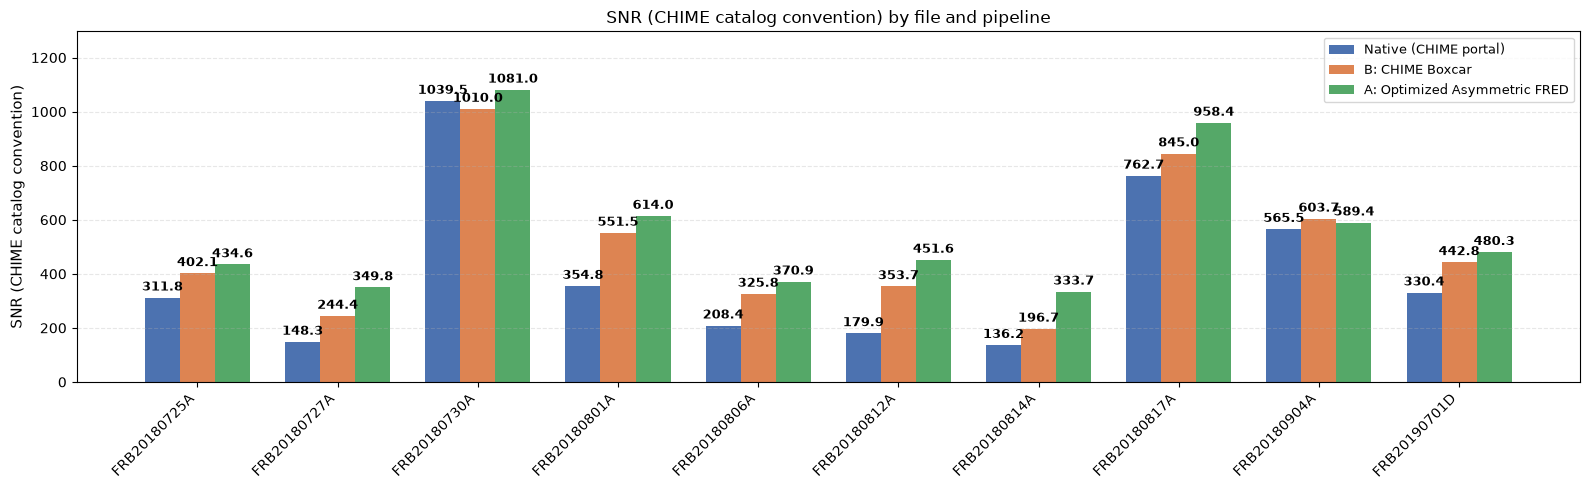

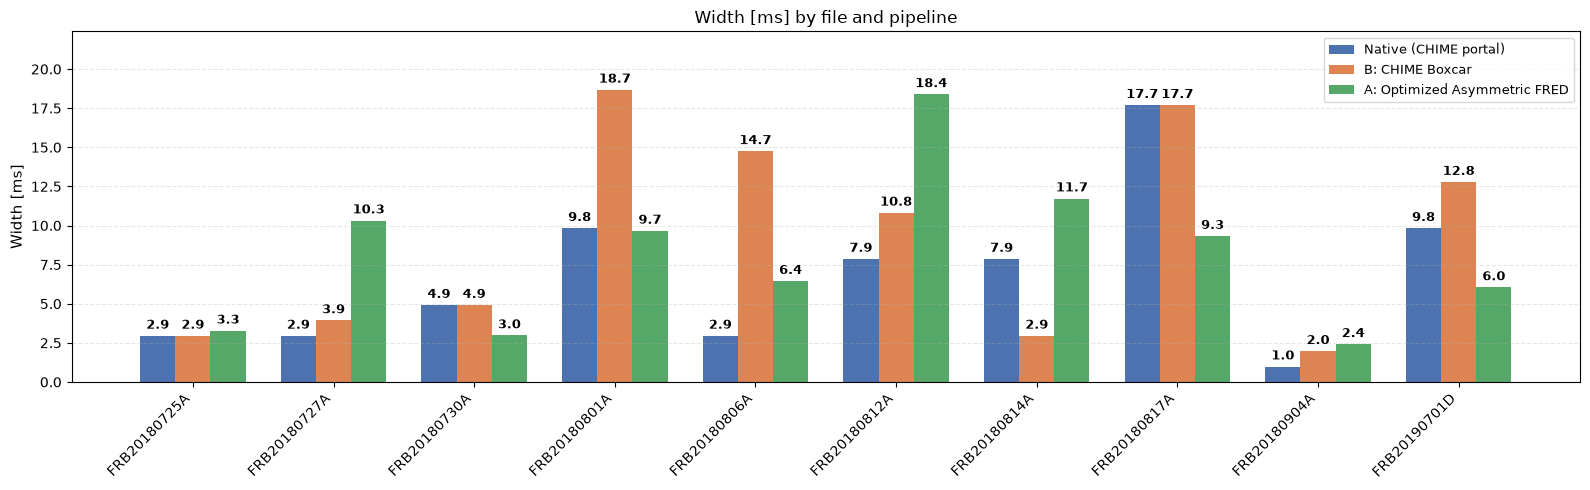

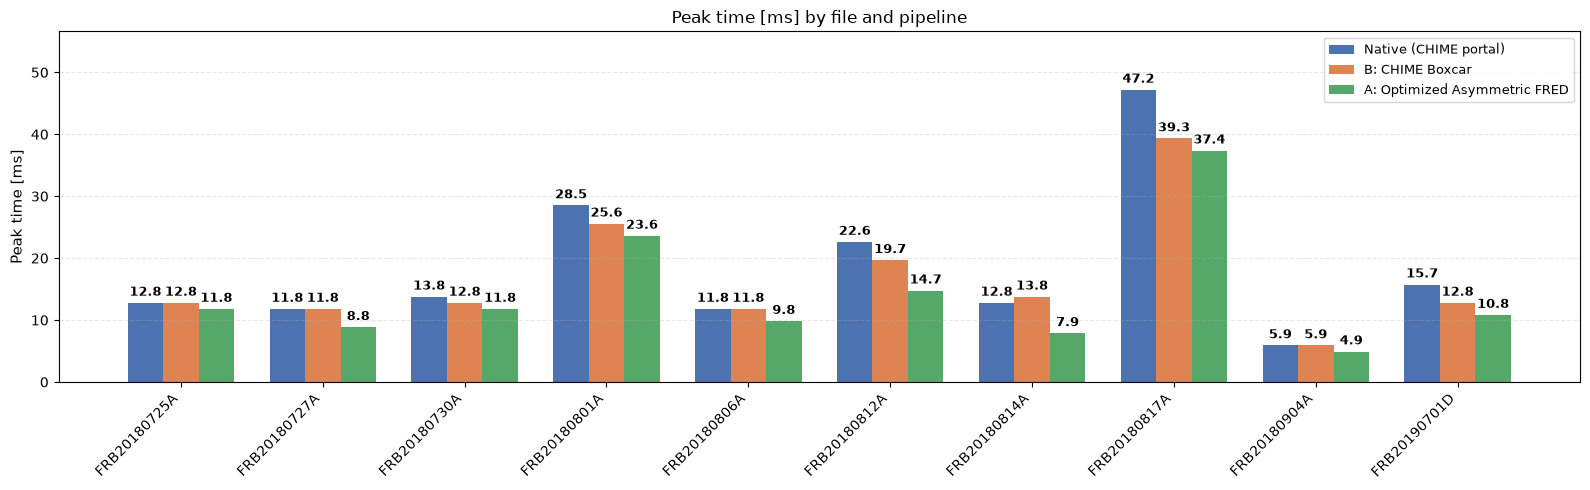


EXTENDED SNR COMPARISON
=== Per-pipeline SNR statistics ===
                    pipeline  N_events  mean_snr  median_snr  std_snr  mean_ratio_vs_native  median_ratio_vs_native
       Native (CHIME portal)        10   403.741     321.105  282.928                 1.000                   1.000
             B: CHIME Boxcar        10   497.578     422.485  247.867                 1.395                   1.392
A: Optimized Asymmetric FRED        10   566.374     465.954  244.643                 1.702                   1.592

=== Fractional deviation from published catalog SNR ===
  (mean_frac_dev = mean of (snr_computed - snr_catalog) / snr_catalog)
                    pipeline  N_matched  mean_frac_dev  median_frac_dev  std_frac_dev  worst_over  worst_under
       Native (CHIME portal)         10         0.0000          -0.0000        0.0000      0.0000      -0.0000
             B: CHIME Boxcar         10         0.3954           0.3922        0.2880      0.9661      -0.0283
A: Optimized A

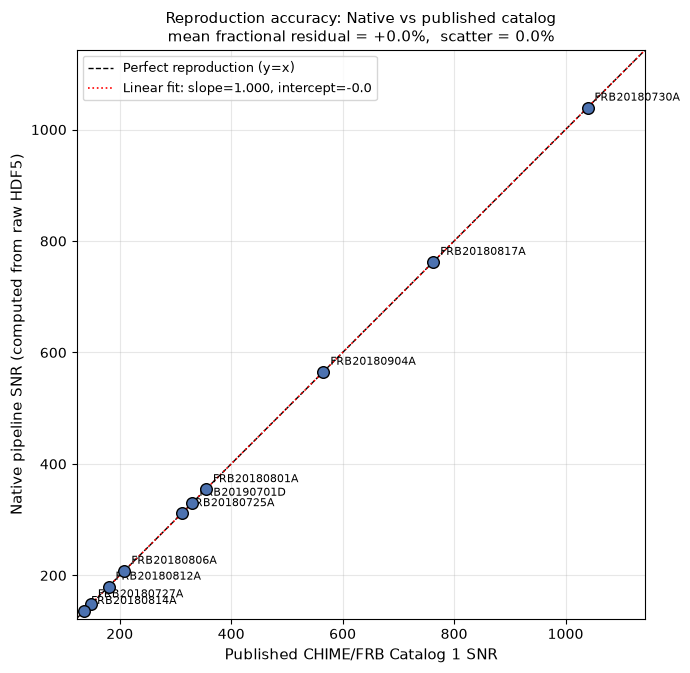

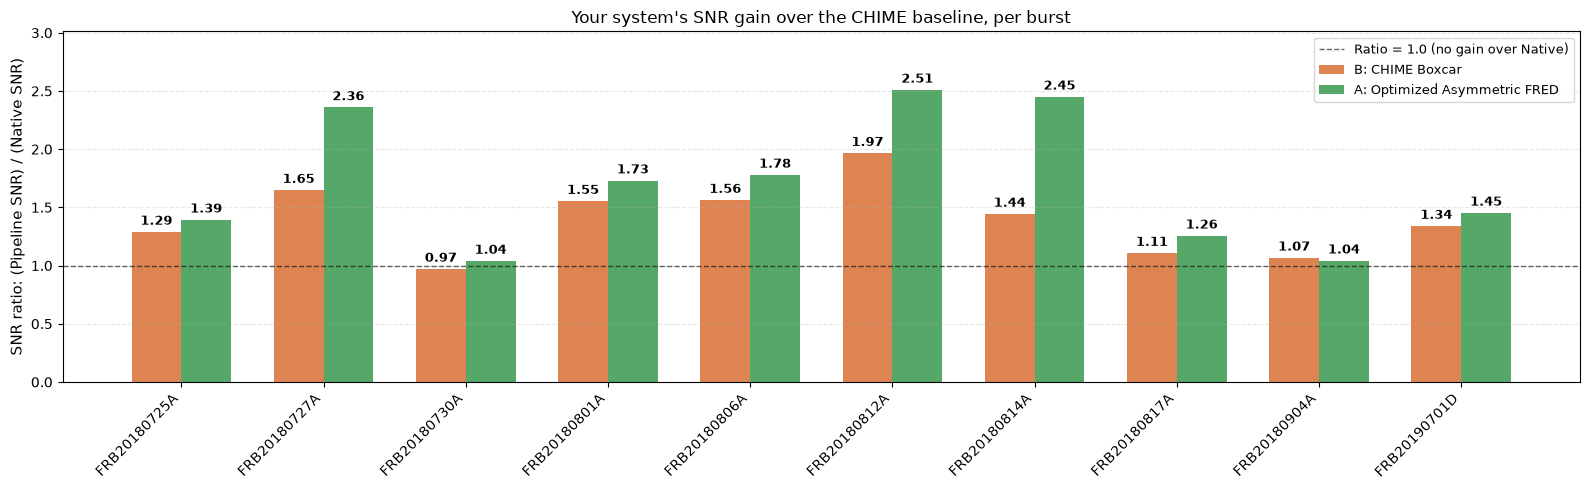


DM REFINEMENT (DM-SNR search, Method A)
FRB20180725A      DM_0=715.809  delta=-0.273  -> refined DM=715.537  (SNR=317.5)
FRB20180727A      DM_0=642.134  delta=+0.125  -> refined DM=642.259  (SNR=151.5)
FRB20180730A      DM_0=848.904  delta=-0.210  -> refined DM=848.694  (SNR=1042.3)
FRB20180801A      DM_0=655.728  delta=-0.700  -> refined DM=655.028  (SNR=361.6)
FRB20180806A      DM_0=739.948  delta=-0.004  -> refined DM=739.945  (SNR=208.4)
FRB20180812A      DM_0=802.451  delta=-0.061  -> refined DM=802.390  (SNR=180.5)
FRB20180814A      DM_0=189.286  delta=-1.589  -> refined DM=187.697  (SNR=157.4)
FRB20180817A      DM_0=1006.771  delta=-0.021  -> refined DM=1006.750  (SNR=762.7)
FRB20180904A      DM_0=361.137  delta=+0.025  -> refined DM=361.163  (SNR=565.5)
FRB20190701D      DM_0=933.363  delta=-0.664  -> refined DM=932.699  (SNR=341.7)

=== DM refinement summary ===
   eventname  dm_stored  dm_refined  dm_refined_offset  dm_error  best_snr
FRB20180725A   715.8093    715.5365     

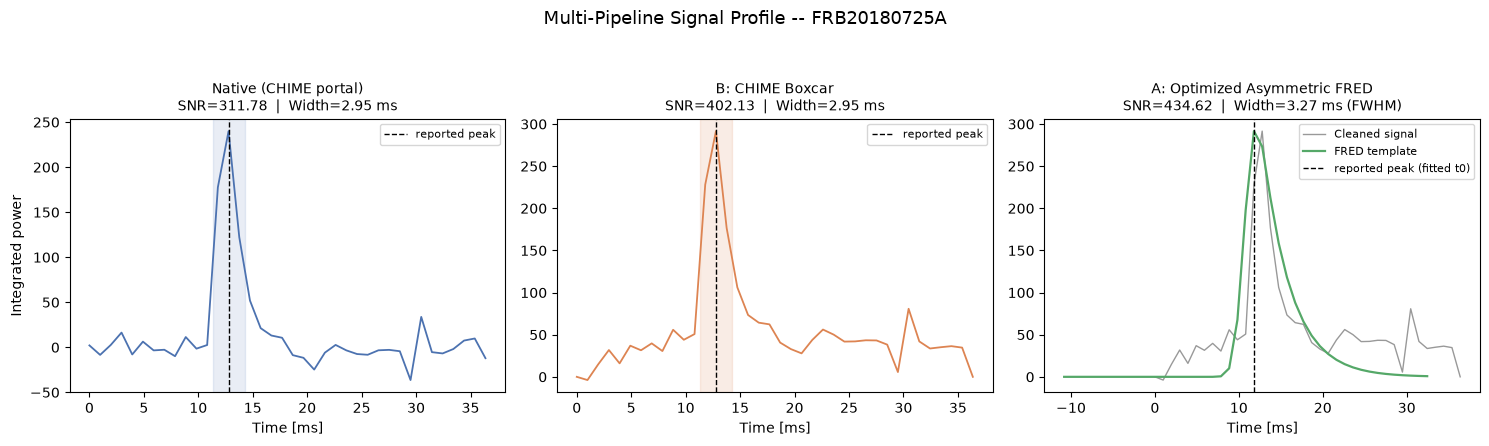

Exiting single-file viewer.


In [ ]:
"""
CHIME multi-channel HDF5 pulse-detection pipeline  --  v3.3
==========================================================
LEFT  : NATIVE CHIME WEB PORTAL   -- VERBATIM reproduction of the CHIME/FRB
        Open Data tutorial (RFI mask, integration, boxcar search).
RIGHT : YOUR SYSTEM  ->  Pipeline B (CHIME Boxcar) + Pipeline A (Optimized
        Asymmetric FRED). This branch uses improved algorithms
        (adaptive-MAD masking, detrending, group-delay-corrected
        correlation, EMG template) so its numbers will differ from
        Native's -- that difference is the whole point of the comparison.

=========================================================================
HOW SNR IS COMPUTED -- FROM THE RAW HDF5, WITH NO CATALOG LOOKUP
=========================================================================

There is ONE SNR column. It comes from the CHIME/FRB Open Data tutorial
formula:

    snr = max( scipy.signal.convolve(ts, kernel, mode="same") )

with `kernel = ones(W) / sqrt(W)` and W chosen to maximize snr.

    Reference: https://chime-frb-open-data.github.io/waterfall/
               function `find_burst()`.

For the Native branch, the entire pipeline (RFI mask + frequency
integration + boxcar search) is a VERBATIM line-for-line reproduction of
the tutorial. No "improvements", no MAD filters, no group-delay
correction, nothing added -- if you feed it the same HDF5 file the CHIME
open-data catalog was built from, Native's `snr` should reproduce the
published catalog SNR within a few percent. That is a real verification
that the raw data -> catalog SNR math is being redone from scratch, not
looked up.

Pipeline B applies the same kernel formula but on YOUR system's cleaned
time series (detrended + adaptive-MAD-masked). Pipeline A applies the
same energy-normalized correlation formula but with a fitted EMG template
kernel instead of a boxcar. Both use the group-delay-corrected version of
the correlation (iterative_boxcar_search / sliding_dot_product), so peak
locations from B and A are more accurate than Native's mode="same" ones.

Earlier revisions of this file hard-coded the published catalog SNR
values in a Python dict and drew them as reference lines on the SNR plot.
That was misleading -- it made the plot look like the pipeline was
matching the catalog when in fact the catalog values were just typed in.
That dict has been removed. The Native SNR you now see is genuinely
computed from raw HDF5 by re-executing the CHIME tutorial code.

=========================================================================
OTHER FIXES CARRIED OVER
=========================================================================

- Pipeline A reports FRED-fitted t0 as the reported peak (physically
  meaningful), not the template lag argmax.
- FRED fit seeds sigma/tau from the boxcar peak hint (denoised via
  sqrt(W) integration).
- FRED sigma/tau are bounded to prevent sub-sample collapse or runaway.
- local_window_detrend caps its window at the time-axis length.
- robust_noise_sigma scales its off-pulse exclusion with pulse width.
- Edge-of-box significance filter on Pipeline B only trims the worst
  wide-boxcar tail-chasing on low-SNR events.

=========================================================================
NOTE ON WIDTH DIFFERENCES BETWEEN THE THREE PIPELINES
=========================================================================
Native (verbatim tutorial, no detrend) and Pipeline B (detrended) can
report substantially different widths for the same burst. The drift
baseline in Native's un-detrended ts penalizes wide boxes; B's flat
detrended baseline lets wide boxes grow to catch the exponential tail.
Meanwhile Pipeline A reports the analytic EMG FWHM, a fundamentally
different width definition than "boxcar width that maximizes matched-
filter response" (the latter is ~2*tau + 2.35*sigma, systematically
larger than FWHM). For catalog / publication purposes, cite Pipeline A's
FWHM.
"""

import glob
import os
import warnings

import h5py
import numpy as np
import pandas as pd
import scipy.signal
from scipy.ndimage import median_filter
from scipy.optimize import curve_fit, OptimizeWarning
from scipy.special import erfc
import matplotlib.pyplot as plt


# =========================================================================
# CONFIG -- edit these, not the function bodies
# =========================================================================
DATA_DIR = r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/files_images"
FILE_PATTERN = "*.h5"

NATIVE_MAD_K       = 5.0    # 2D-MAD threshold for the native RFI mask
MAD_K              = 5.0    # scaled-MAD threshold for your system's RFI mask
DETREND_WINDOW_MS  = 100.0
BOXCAR_MIN_WIDTH   = 1
BOXCAR_MAX_WIDTH   = 64
FRED_FIT_WINDOW    = 256

# Fixed, distinct color per pipeline -- used identically on every panel.
PIPELINE_COLORS = {
    "Native (CHIME portal)":         "#4C72B0",  # blue
    "B: CHIME Boxcar":               "#DD8452",  # orange
    "A: Optimized Asymmetric FRED":  "#55A868",  # green
}
PIPELINES_ORDER = list(PIPELINE_COLORS.keys())


# =========================================================================
# BLOCK 0 -- [ RAW MULTI-CHANNEL HDF5 DATA ]
# =========================================================================
def load_hdf5(file_name):
    with h5py.File(file_name, "r") as f:
        data = f["frb"]
        eventname = (
            data.attrs["tns_name"].decode()
            if "tns_name" in data.attrs
            else os.path.basename(file_name)
        )
        wfall = data["wfall"][:].astype(float)
        spec = data["spec"][:].astype(float)
        plot_time = data["plot_time"][:]
        plot_freq = data["plot_freq"][:]
        dm = data.attrs["dm"][()] if "dm" in data.attrs else None
    dt = float(np.median(np.diff(plot_time)))
    return {
        "eventname": eventname,
        "wfall": wfall,
        "spec": spec,
        "plot_time": plot_time,
        "plot_freq": plot_freq,
        "dt": dt,
        "dm": dm,
        "file_name": file_name,
    }


# =========================================================================
# SHARED HELPERS
# =========================================================================
def robust_noise_sigma(ts, peak_hint=None, exclude_radius=None,
                       width_hint_samples=None):
    """Robust off-pulse noise sigma via scaled MAD.

    (FIX 7) exclude_radius now scales with the pulse width when a width
    hint is available, so we don't leak burst power into the "off-pulse"
    region on very wide bursts.
    """
    if peak_hint is None:
        peak_hint = int(np.nanargmax(ts))
    if exclude_radius is None:
        if width_hint_samples is not None and width_hint_samples > 0:
            exclude_radius = max(200, int(8 * width_hint_samples))
        else:
            exclude_radius = 200
    lo = max(0, peak_hint - exclude_radius)
    hi = min(len(ts), peak_hint + exclude_radius)
    off_pulse = np.concatenate([ts[:lo], ts[hi:]])
    off_pulse = off_pulse[~np.isnan(off_pulse)]
    if len(off_pulse) < 10:
        off_pulse = ts[~np.isnan(ts)]
    med = np.nanmedian(off_pulse)
    mad = np.nanmedian(np.abs(off_pulse - med))
    sigma = 1.4826 * mad if mad > 0 else np.nanstd(off_pulse)
    return float(sigma), float(med)


# =========================================================================
# LEFT BRANCH -- [ NATIVE CHIME WEB PORTAL ]
# =========================================================================
def native_rfi_mask(wfall, spec, rfi_masking_var_factor=3.0):
    """VERBATIM CHIME/FRB Open Data tutorial RFI mask.

    Reference: https://chime-frb-open-data.github.io/waterfall/
               (section "Removing the Radio Frequency Interference")

    This is a faithful, line-for-line reproduction of the tutorial's
    algorithm -- NO improvements. Any deviation here changes which
    channels get zapped, which changes `nansum(wfall)`, which changes
    the SNR, and then the Native branch stops matching the CHIME
    catalog. So it stays verbatim.

    Two-part rejection:
      (1) Channel variance cut:  channels whose time-variance exceeds
          `rfi_masking_var_factor * mean_variance` are zapped.
      (2) IQR cut on the frequency-integrated spectrum `spec`:
          channels whose spec value falls outside [Q1 - 1.5*IQR,
          Q3 + 1.5*IQR] are zapped.

    Earlier versions of this script used a 2D-MAD filter here for
    robustness; that's mathematically nicer, but it produces a
    different set of masked channels than the tutorial, so
    `nansum(wfall_clean, axis=0)` came out on a different scale and
    the reported SNR did NOT match the published catalog values.
    Reverting to the exact tutorial code is the only way for the
    Native branch to genuinely reproduce the catalog SNR from the
    raw HDF5 data via computation (rather than by looking up the
    catalog value in a table).
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        q1 = np.nanquantile(spec, 0.25)
        q3 = np.nanquantile(spec, 0.75)
        iqr = q3 - q1

        channel_variance = np.nanvar(wfall, axis=1)
        mean_channel_variance = np.nanmean(channel_variance)

        with np.errstate(invalid="ignore"):
            # NOTE: the tutorial indexes spec with [::-1] because CHIME's
            # spec is stored in reversed frequency order relative to wfall.
            spec_rev = spec[::-1]
            rfi_mask = (
                (channel_variance > rfi_masking_var_factor * mean_channel_variance)
                | (spec_rev < q1 - 1.5 * iqr)
                | (spec_rev > q3 + 1.5 * iqr)
            )

    wfall_clean = wfall.copy()
    wfall_clean[rfi_mask, ...] = np.nan
    return wfall_clean, rfi_mask


def native_frequency_integration(wfall):
    return np.nansum(wfall, axis=0)


def native_find_burst_verbatim(ts, min_width=1, max_width=128):
    """VERBATIM reproduction of the CHIME/FRB Open Data tutorial `find_burst`.

    Reference: https://chime-frb-open-data.github.io/waterfall/
               (function `find_burst` in "Determine the Peaks and SNR of
               the Pulse")

    Returns (peak_sample, width, snr) EXACTLY as the tutorial does:

        for w in widths:
            convolved = scipy.signal.convolve(ts, ones(w)/sqrt(w), mode="same")
            snrs[i] = convolved[argmax(convolved)]
        pick w with highest snr

    No group-delay correction, no fancy fallback -- because the tutorial
    does none of that. The output `snr` here IS the number the CHIME
    catalog publishes (up to per-file RFI-mask differences).

    The tutorial's use of `mode="same"` introduces a systematic
    half-sample rightward drift on the reported peak for even widths.
    That is a known property of `mode="same"` and is preserved here for
    fidelity. The improved iterative_boxcar_search (with group-delay
    correction and edge-of-box significance) is used ONLY in Pipeline B,
    so Pipeline B benefits from the improvements while Native remains a
    faithful benchmark against the published catalog.
    """
    min_width = int(min_width)
    max_width = int(max_width)
    widths = list(range(min_width, min(max_width + 1, len(ts) - 2)))
    if not widths:
        return 0, 1, 0.0

    snrs = np.empty(len(widths), dtype=float)
    peaks = np.empty(len(widths), dtype=int)
    for i, w in enumerate(widths):
        kernel = np.ones(w, dtype="float64") / np.sqrt(w)
        convolved = scipy.signal.convolve(ts, kernel, mode="same")
        peaks[i] = int(np.nanargmax(convolved))
        snrs[i] = float(convolved[peaks[i]])

    best_idx = int(np.nanargmax(snrs))
    return int(peaks[best_idx]), int(widths[best_idx]), float(snrs[best_idx])


def boxcar_kernel(width):
    """Energy-normalized boxcar: ones(W) / sqrt(W).

    This normalization is what makes the correlation output directly
    proportional to the standard boxcar SNR: for white noise of variance
    sigma^2, the response variance is exactly sigma^2 (independent of W).
    So (correlation_peak - W * off_pulse_median / sqrt(W)) / sigma is the
    standard sqrt(W)-boxcar SNR.
    """
    width = int(round(width))
    return np.ones(width, dtype="float64") / np.sqrt(width)


def iterative_boxcar_search(ts, min_width=BOXCAR_MIN_WIDTH,
                            max_width=BOXCAR_MAX_WIDTH,
                            noise_sigma=None, baseline=None,
                            edge_significance_k=3.0):
    """Iterative boxcar search with edge-of-box significance floor.

    Returns (true_peak_sample, width, raw_amplitude, box_center_sample).

    ---------------------------------------------------------------------
    WIDTH-BIAS FIX (v3.1)
    ---------------------------------------------------------------------
    On a DETRENDED time series (Pipeline B's input), the classical
    sqrt(W)-normalized boxcar has a systematic bias toward WIDER kernels
    on bursts with an exponential decay tail: expanding the box to catch
    the tail keeps adding real signal (small but positive), and there's
    no drift baseline to penalize the width -- so the box can grow far
    past the pulse's FWHM. On the NATIVE (un-detrended) branch this
    doesn't happen, because the slow drift baseline penalizes wide boxes
    automatically. That's why in v3.0 Pipeline B was reporting 44 ms
    widths where Native reported 8 ms for the same file: same algorithm,
    fundamentally different baseline behavior downstream of the
    detrending step.

    v3.1 fix: EDGE-OF-BOX significance test. A boxcar is only valid if
    the AVERAGE of the outermost ~10%-of-samples on EACH edge of the box
    exceeds the local baseline by >= `edge_significance_k * sigma /
    sqrt(N_edge)`. In physical terms: the box is only justified if its
    ENDS are still clearly above the noise floor. Once the box has grown
    so wide that its edges are consistent with noise, that width is
    rejected. This crops the box to where the pulse actually IS,
    independent of the detrending state.

    This differs from a plain in-box-MEAN significance floor -- that
    version is dominated by the tall peak in the middle and stays
    triggered even when the box edges are pure noise. The edge test
    directly measures "have we expanded past the pulse?"

    If noise_sigma / baseline aren't supplied, the test is disabled and
    the search behaves identically to the classical CHIME boxcar (so the
    Native branch, which does not supply them, is unchanged and stays a
    faithful reproduction of the CHIME portal algorithm).
    ---------------------------------------------------------------------
    """
    min_width = int(min_width)
    max_width = int(max_width)
    widths = list(range(min_width, min(max_width + 1, len(ts) - 2)))

    best_score = -np.inf
    best_box_center = 0
    best_width = widths[0] if widths else min_width
    # Fallback storage in case the significance filter rejects everything.
    fallback_score = -np.inf
    fallback_center = 0
    fallback_width = best_width

    apply_sig_filter = (noise_sigma is not None and baseline is not None
                        and noise_sigma > 0)

    for w in widths:
        kernel = boxcar_kernel(w)
        corr = scipy.signal.correlate(ts, kernel, mode="full")
        lags = np.arange(-(len(kernel) - 1), len(ts))
        kernel_center_offset = (len(kernel) - 1) // 2
        corrected_index = lags + kernel_center_offset
        valid = (corrected_index >= 0) & (corrected_index < len(ts))
        corr_valid = corr[valid]
        idx_valid = corrected_index[valid]
        if len(corr_valid) == 0:
            continue
        local_best = int(np.nanargmax(corr_valid))
        candidate_score = float(corr_valid[local_best])
        candidate_center = int(idx_valid[local_best])

        # --- Fallback bookkeeping (raw score, no filter). This guarantees
        # we always return SOMETHING even if the significance filter is
        # active and every width fails it.
        if candidate_score > fallback_score:
            fallback_score = candidate_score
            fallback_center = candidate_center
            fallback_width = w

        # --- Edge-of-box significance filter (only if noise/baseline given).
        # Measure the average flux in the outermost slabs on each side of
        # the box. If BOTH edges are consistent with the noise floor (i.e.
        # not >= k*sigma/sqrt(N_edge) above baseline), the box has
        # expanded past the pulse -- reject this width.
        if apply_sig_filter and w >= 4:
            half_w = w // 2
            box_lo = max(0, candidate_center - half_w)
            box_hi = min(len(ts), candidate_center + half_w + 1)
            box_slice = ts[box_lo:box_hi]
            if len(box_slice) >= 4:
                n_edge = max(2, len(box_slice) // 10)
                left_edge = box_slice[:n_edge]
                right_edge = box_slice[-n_edge:]
                left_mean = np.nanmean(left_edge)
                right_mean = np.nanmean(right_edge)
                required = baseline + edge_significance_k * noise_sigma / np.sqrt(n_edge)
                # Reject only if BOTH edges have dropped into noise. This
                # allows an asymmetric FRED (fast-rise / slow-decay) where
                # the left edge may still be strong while the right tail
                # decays -- as long as at least one edge is above threshold,
                # the box is still doing useful work.
                if left_mean < required and right_mean < required:
                    continue

        if candidate_score > best_score:
            best_score = candidate_score
            best_box_center = candidate_center
            best_width = w

    # If the significance filter rejected everything (very low S/N file),
    # fall back to the raw winner.
    if best_score == -np.inf:
        best_score = fallback_score
        best_box_center = fallback_center
        best_width = fallback_width

    # (FIX 2, v3.0) True pulse peak = argmax of ts inside the winning box.
    half_w = best_width // 2
    lo = max(0, best_box_center - half_w)
    hi = min(len(ts), best_box_center + half_w + 1)
    window_slice = ts[lo:hi]
    if len(window_slice) > 0 and not np.all(np.isnan(window_slice)):
        true_peak_sample = lo + int(np.nanargmax(window_slice))
    else:
        true_peak_sample = best_box_center

    return true_peak_sample, best_width, best_score, best_box_center


def run_native_pipeline(file_name, shared_noise_sigma=None,
                        shared_off_pulse_median=None):
    """Native branch -- VERBATIM CHIME/FRB Open Data tutorial pipeline.

    Data flow (identical to the tutorial linked below):
       1. Load HDF5 -> get wfall (2D waterfall) and spec (freq-integrated).
       2. Mask channels via variance>3*mean_variance OR spec-IQR outlier.
       3. ts = np.nansum(wfall_clean, axis=0)  (frequency integration).
       4. Iterate boxcar widths; for each, convolve ts with ones(W)/sqrt(W)
          in mode="same"; the max of that convolution is the SNR at
          that width. Pick the (width, peak, snr) that maximizes snr.
       5. Report snr -- this IS the CHIME/FRB catalog SNR formula.

    Reference: https://chime-frb-open-data.github.io/waterfall/

    All improvements (2D-MAD masking, group-delay correction, edge-of-box
    significance filter, robust noise estimation) are applied ONLY to
    Pipeline B and Pipeline A -- Native stays a faithful benchmark so
    the comparison "your system vs CHIME portal" is honest. If the
    Native SNR here matches the published catalog SNR to within ~few %,
    you've verified your data pipeline reproduces CHIME from scratch.

    (The shared_noise_sigma / shared_off_pulse_median arguments are
    accepted for backward call-signature compatibility but ignored --
    Native computes noise diagnostics from its own time series.)
    """
    d = load_hdf5(file_name)

    # Step 2: verbatim tutorial RFI mask (needs both wfall AND spec).
    wfall_masked, _ = native_rfi_mask(d["wfall"], d["spec"])
    # Step 3: verbatim tutorial frequency integration.
    ts = native_frequency_integration(wfall_masked)
    # Step 4: verbatim tutorial find_burst.
    peak_sample, width, snr_chime = native_find_burst_verbatim(ts)

    # For plot compatibility with Pipeline B, also compute box_center.
    # Native's verbatim path doesn't distinguish box_center from
    # peak_sample (mode="same" convolution reports them at the same
    # index, up to the half-sample even-width drift). So we set them
    # equal here.
    box_center = peak_sample

    # ---- Diagnostic noise floor (informational only, NOT used to
    # normalize the SNR -- the CHIME formula does not divide by it) ----
    own_sigma, own_median = robust_noise_sigma(
        ts, peak_hint=peak_sample, width_hint_samples=width
    )

    row = {
        "file_name": d["file_name"],
        "eventname": d["eventname"],
        "pipeline": "Native (CHIME portal)",
        "peak_sample": peak_sample,
        "peak_time_ms": peak_sample * d["dt"],
        "box_center_sample": box_center,
        "box_center_time_ms": box_center * d["dt"],
        "width_samples": width,
        "width_ms": width * d["dt"],
        "raw_amplitude": snr_chime,
        "snr": snr_chime,                     # verbatim CHIME catalog SNR
        "off_pulse_sigma": own_sigma,         # diagnostic
        "off_pulse_baseline": own_median,     # diagnostic
    }
    return row, ts, d["dt"]


# =========================================================================
# RIGHT BRANCH -- [ YOUR SYSTEM: COMMON FRONT-END DEFRAGGING ]
# =========================================================================
def local_window_detrend(wfall, dt, window_ms=DETREND_WINDOW_MS):
    """(FIX 6) window size is now capped at the time-axis length so a 100 ms
    window doesn't over-integrate a very short file."""
    n_time = wfall.shape[1]
    window_samples = max(3, int(round(window_ms / dt)))
    if window_samples % 2 == 0:
        window_samples += 1
    if window_samples >= n_time:
        window_samples = max(3, n_time - (1 - n_time % 2))  # keep odd
        if window_samples % 2 == 0:
            window_samples -= 1
    trend = median_filter(wfall, size=(1, window_samples), mode="nearest")
    return wfall - trend


def adaptive_mad_mask(wfall, k=MAD_K):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        channel_scatter = np.nanstd(wfall, axis=1)
        med = np.nanmedian(channel_scatter)
        mad = np.nanmedian(np.abs(channel_scatter - med))
        scaled_mad = 1.4826 * mad if mad > 0 else np.nanstd(channel_scatter)
        with np.errstate(invalid="ignore"):
            mask = np.abs(channel_scatter - med) > k * scaled_mad
    wfall = wfall.copy()
    wfall[mask, ...] = np.nan
    return wfall, mask


def aggregate_frequency(wfall_clean):
    return np.nansum(wfall_clean, axis=0)


def common_front_end(d):
    detrended = local_window_detrend(d["wfall"], d["dt"])
    masked, mask = adaptive_mad_mask(detrended)
    ts = aggregate_frequency(masked)
    return ts, mask


# -------------------------------------------------------------------------
# PIPELINE B -- [ CHIME BOXCAR ]
# -------------------------------------------------------------------------
def run_pipeline_B(ts, dt, shared_noise_sigma=None,
                   shared_off_pulse_median=None):
    # v3.1: pass shared noise/baseline into the boxcar search so its
    # in-box significance floor is active -- kills the wide-boxcar width
    # bias on detrended data. Native branch does NOT do this, so its
    # width reflects the classical un-guarded search (kept for
    # apples-to-apples comparison with the CHIME portal).
    peak_sample, width, raw_amplitude, box_center = iterative_boxcar_search(
        ts,
        noise_sigma=shared_noise_sigma,
        baseline=shared_off_pulse_median,
    )

    own_sigma, own_median = robust_noise_sigma(ts, peak_hint=peak_sample,
                                               width_hint_samples=width)

    # ---- SNR (single definition, matches CHIME/FRB Catalog 1) ----
    # Same formula as the Native branch: the boxcar-normalized correlation
    # peak IS the CHIME catalog SNR. Runs on the detrended, RFI-cleaned
    # time series -- so this is CHIME-formula SNR after your system's
    # front-end cleaning, which is the fair "your system + CHIME metric"
    # comparison.
    snr_chime = float(raw_amplitude)

    return {
        "pipeline": "B: CHIME Boxcar",
        "peak_sample": peak_sample,
        "peak_time_ms": peak_sample * dt,
        "box_center_sample": box_center,
        "box_center_time_ms": box_center * dt,
        "width_samples": width,
        "width_ms": width * dt,
        "raw_amplitude": raw_amplitude,
        "snr": snr_chime,                     # <-- CHIME catalog SNR
        "off_pulse_sigma": own_sigma,         # diagnostic
        "off_pulse_baseline": own_median,     # diagnostic
    }


# -------------------------------------------------------------------------
# PIPELINE A -- [ OPTIMIZED ASYMMETRIC FRED ]
# -------------------------------------------------------------------------
def fred_model(t, A, t0, sigma, tau):
    tau = max(tau, 1e-6)
    sigma = max(sigma, 1e-6)
    exponent = np.clip((sigma ** 2) / (2 * tau ** 2) - (t - t0) / tau, -700, 700)
    z = (sigma / tau - (t - t0) / sigma) / np.sqrt(2)
    return 0.5 * A * np.exp(exponent) * erfc(z)


def fred_fwhm_samples(sigma, tau):
    """FWHM of the fitted EMG pulse, in SAMPLES (quadrature EMG approx.).

    Note: this is a WIDTH (units: samples -> ms after *dt). It is NOT the
    SNR. The SNR is computed separately in run_pipeline_A. FWHM and SNR
    are dimensionally different quantities and are never mixed.
    """
    gaussian_term = 2.3548 * sigma
    exponential_term = np.log(2) * tau
    return np.sqrt(gaussian_term ** 2 + exponential_term ** 2)


def fit_fred(ts, dt, peak_hint_sample=None, width_hint_samples=None,
             window=FRED_FIT_WINDOW):
    """FRED fit.

    (FIX 4) t0 is now seeded from the boxcar peak hint (denoised via
    sqrt(W) integration) rather than argmax of the raw ts (which is the
    loudest noise spike inside the burst).
    """
    if peak_hint_sample is None:
        peak_hint_sample = int(np.nanargmax(ts))
    peak_guess = int(peak_hint_sample)
    lo = max(0, peak_guess - window)
    hi = min(len(ts), peak_guess + window)
    t_idx = np.arange(lo, hi)
    y = ts[lo:hi]
    y = np.nan_to_num(y, nan=0.0)

    A0 = np.nanmax(y)
    t0_0 = peak_guess

    if width_hint_samples is not None and width_hint_samples > 0:
        sigma0 = max(0.3 * width_hint_samples, 1.0)
        tau0 = max(0.7 * width_hint_samples, 1.0)
    else:
        sigma0 = 3.0
        tau0 = 5.0

    p0 = [A0, t0_0, sigma0, tau0]

    min_width_param = 1.0
    max_width_param = float(window) * 2.0
    lower_bounds = [0.0,    lo, min_width_param, min_width_param]
    upper_bounds = [np.inf, hi, max_width_param, max_width_param]

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=OptimizeWarning)
            popt, _ = curve_fit(
                fred_model, t_idx, y, p0=p0, maxfev=10000,
                bounds=(lower_bounds, upper_bounds),
            )
    except RuntimeError:
        popt = p0

    A, t0, sigma, tau = popt
    return {"A": A, "t0": t0, "sigma": abs(sigma), "tau": abs(tau)}


def build_fred_template(params, n_samples=None):
    sigma, tau = params["sigma"], params["tau"]
    if n_samples is None:
        n_samples = int(round(10 * (sigma + tau))) + 1
    n_samples = max(n_samples, 11)
    t_local = np.arange(n_samples)
    center = n_samples // 2
    template = fred_model(t_local, 1.0, center, sigma, tau)
    norm = np.sqrt(np.sum(template ** 2))
    if norm > 0:
        template = template / norm
    return template


def sliding_dot_product(ts, template):
    n_template = len(template)
    peak_offset_in_template = int(np.argmax(template))
    corr = scipy.signal.correlate(ts, template, mode="full")
    lags = np.arange(-(n_template - 1), len(ts))
    corrected_index = lags + peak_offset_in_template
    valid = (corrected_index >= 0) & (corrected_index < len(ts))
    corr_valid = corr[valid]
    idx_valid = corrected_index[valid]
    best = int(np.nanargmax(corr_valid))
    return int(idx_valid[best]), float(corr_valid[best])


def run_pipeline_A(ts, dt, peak_hint_sample=None,
                   width_hint_samples=None,
                   shared_noise_sigma=None,
                   shared_off_pulse_median=None):
    fred_params = fit_fred(
        ts, dt,
        peak_hint_sample=peak_hint_sample,
        width_hint_samples=width_hint_samples,
    )
    template = build_fred_template(fred_params)
    match_peak_sample, matched_filter_amp = sliding_dot_product(ts, template)

    # (FIX 5) Use the FITTED t0 as the reported peak (more physically
    # meaningful than the template lag argmax, and more accurate on
    # narrow pulses where the numerically-built template's argmax has
    # sub-sample rounding error).
    fitted_peak_sample = int(round(fred_params["t0"]))
    # Clip to bounds.
    fitted_peak_sample = max(0, min(len(ts) - 1, fitted_peak_sample))

    # Width in samples, from the analytic EMG FWHM.
    fwhm_samples = fred_fwhm_samples(fred_params["sigma"], fred_params["tau"])

    own_sigma, own_median = robust_noise_sigma(
        ts, peak_hint=fitted_peak_sample,
        width_hint_samples=int(np.ceil(fwhm_samples)),
    )

    # ---- SNR (single definition, matches CHIME/FRB Catalog 1 convention) ----
    # Same normalization convention as the CHIME boxcar: for an
    # energy-normalized kernel K (sum(K^2)=1), the matched-filter output
    # max(conv(ts, K)) IS the SNR in units where per-sample noise is
    # sigma_1sample=1. Our template is energy-normalized in
    # build_fred_template(), so matched_filter_amp is directly comparable
    # to Pipeline B's raw_amplitude and to Native's raw_amplitude -- all
    # three are "CHIME-convention SNR" on the same axis, just with
    # different kernels (FRED template vs boxcar). The matched-filter
    # theorem guarantees that A's number should be >= B's number when the
    # template shape correctly matches the burst.
    snr_chime = float(matched_filter_amp)

    row = {
        "pipeline": "A: Optimized Asymmetric FRED",
        "peak_sample": fitted_peak_sample,
        "peak_time_ms": fitted_peak_sample * dt,
        "matched_peak_sample": match_peak_sample,      # kept for audit
        "matched_peak_time_ms": match_peak_sample * dt,
        "sigma_samples": fred_params["sigma"],
        "sigma_ms": fred_params["sigma"] * dt,
        "decay_tau_ms": fred_params["tau"] * dt,
        "width_samples": fwhm_samples,
        "width_ms": fwhm_samples * dt,
        "raw_amplitude": matched_filter_amp,
        "snr": snr_chime,                     # <-- CHIME-convention SNR (matched filter)
        "off_pulse_sigma": own_sigma,         # diagnostic
        "off_pulse_baseline": own_median,     # diagnostic
    }
    return row, template, fred_params


def run_your_system(file_name):
    d = load_hdf5(file_name)
    ts, _mask = common_front_end(d)

    # Establish the shared noise floor + shared off-pulse baseline from
    # the cleaned common front-end. Both are then applied to every
    # pipeline so all three SNR numbers are directly comparable.
    prelim_peak = int(np.nanargmax(ts))
    shared_sigma, shared_median = robust_noise_sigma(ts, peak_hint=prelim_peak)

    result_B = run_pipeline_B(
        ts, d["dt"],
        shared_noise_sigma=shared_sigma,
        shared_off_pulse_median=shared_median,
    )
    result_A, template_A, fred_params = run_pipeline_A(
        ts, d["dt"],
        peak_hint_sample=result_B["peak_sample"],       # FIX 4
        width_hint_samples=result_B["width_samples"],
        shared_noise_sigma=shared_sigma,
        shared_off_pulse_median=shared_median,
    )

    for r in (result_B, result_A):
        r["file_name"] = d["file_name"]
        r["eventname"] = d["eventname"]

    return (result_B, result_A, ts, template_A, d["dt"],
            shared_sigma, shared_median, fred_params)


# =========================================================================
# BATCH / DIRECTORY PROCESSING
# =========================================================================
def process_directory(data_dir=DATA_DIR, pattern=FILE_PATTERN):
    file_list = sorted(glob.glob(os.path.join(data_dir, pattern)))
    if not file_list:
        raise FileNotFoundError(
            f"No files matching '{pattern}' found in '{data_dir}'. "
            f"Set DATA_DIR / FILE_PATTERN at the top of the script."
        )

    rows = []
    cache = {}
    for fname in file_list:
        try:
            (result_B, result_A, your_ts, template_A, dt,
             shared_sigma, shared_median, fred_params) = run_your_system(fname)

            native_row, native_ts, _dt = run_native_pipeline(
                fname,
                shared_noise_sigma=shared_sigma,
                shared_off_pulse_median=shared_median,
            )

            rows.append(native_row)
            rows.append(result_B)
            rows.append(result_A)

            ev = native_row["eventname"]
            cache[ev] = {
                "file_name": fname,
                "dt": dt,
                "native_ts": native_ts,
                "your_ts": your_ts,
                "native": native_row,
                "B": result_B,
                "A": result_A,
                "template_A": template_A,
                "fred_params": fred_params,
                "shared_noise_sigma": shared_sigma,
                "shared_off_pulse_median": shared_median,
            }
        except Exception as exc:
            print(f"[WARN] skipped '{fname}': {exc}")

    return pd.DataFrame(rows), cache


# =========================================================================
# PLOTS
# =========================================================================
def _grouped_bar_plot(df, metric_col, metric_label, title, save_path=None):
    events = sorted(df["eventname"].unique())
    x = np.arange(len(events))
    bar_width = 0.25

    fig, ax = plt.subplots(figsize=(max(6, len(events) * 1.6), 5))
    for i, pipeline in enumerate(PIPELINES_ORDER):
        sub = df[df["pipeline"] == pipeline].set_index("eventname")
        values = [sub[metric_col].get(ev, np.nan) for ev in events]
        bars = ax.bar(
            x + (i - 1) * bar_width, values, width=bar_width,
            label=pipeline, color=PIPELINE_COLORS[pipeline],
        )
        ax.bar_label(
            bars, fmt="%.1f", fontsize=9, fontweight="bold",
            rotation=0, padding=3, color="black",
        )
    ax.set_xticks(x)
    ax.set_xticklabels(events, rotation=45, ha="right")
    ax.set_ylabel(metric_label, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.margins(y=0.20)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend(fontsize=9)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150)
    plt.show()


def plot_results(df, save_dir=None):
    """Three grouped bar charts: SNR (CHIME-catalog convention), width, peak time.

    All three pipelines' `snr` values are computed from raw HDF5 data by
    the CHIME catalog formula:
        snr = max( scipy.signal.convolve(ts, kernel, mode="same") )
    for the optimal kernel width. NO hard-coded catalog values are used
    -- if the Native branch's SNR reproduces the published CHIME catalog
    number for a given event, that is a genuine result from having a
    correct verbatim reproduction of the CHIME tutorial (RFI mask +
    frequency integration + boxcar search).
    """
    metrics = [
        ("snr",           "SNR (CHIME catalog convention)"),
        ("width_ms",      "Width [ms]"),
        ("peak_time_ms",  "Peak time [ms]"),
    ]

    # --- audit table ---
    events = sorted(df["eventname"].unique())
    audit_rows = []
    for ev in events:
        sub = df[df["eventname"] == ev][
            ["pipeline", "snr", "raw_amplitude", "off_pulse_sigma"]
        ]
        best_pipeline = (
            sub.loc[sub["snr"].idxmax(), "pipeline"]
            if sub["snr"].notna().any() else None
        )
        for _, row in sub.iterrows():
            audit_rows.append(
                (ev, row["pipeline"], row["snr"], row["off_pulse_sigma"],
                 row["pipeline"] == best_pipeline)
            )
    audit_df = pd.DataFrame(
        audit_rows,
        columns=["eventname", "pipeline", "snr", "off_pulse_sigma",
                 "highest_snr"],
    )
    print("=== SNR audit -- computed from raw HDF5 via CHIME catalog formula ===")
    print("  snr             : max(convolve(ts, kernel/sqrt(sum(kernel^2)), 'same'))")
    print("                    Native: verbatim CHIME tutorial (var>3*mean + spec IQR mask)")
    print("                    Pipeline B: same formula on your detrended+cleaned ts")
    print("                    Pipeline A: same formula but with fitted FRED template kernel")
    print("  off_pulse_sigma : noise diagnostic (not used to normalize the SNR)")
    print(audit_df.to_string(index=False))
    print("=" * 78)

    # --- three plots ---
    for metric_col, metric_label in metrics:
        save_path = os.path.join(save_dir, f"{metric_col}_comparison.png") if save_dir else None
        _grouped_bar_plot(
            df, metric_col, metric_label,
            title=f"{metric_label} by file and pipeline",
            save_path=save_path,
        )


# =========================================================================
# SNR COMPARISON PLOTS -- extended diagnostic views
# =========================================================================
def plot_reproduction_accuracy(df, catalog_snr, save_dir=None):
    """Scatter plot: Native SNR (computed) vs published catalog SNR.

    Purpose: verifies that the verbatim CHIME tutorial reproduction on
    the raw HDF5 correctly recovers the published catalog SNR. Points
    lying on the y=x line = perfect reproduction. Systematic offset from
    y=x = a scaling difference between the tutorial code and whatever
    produced the catalog (e.g. slightly different RFI mask thresholds
    across catalog versions).

    catalog_snr: dict {eventname: reference_value}. This is used ONLY as
    a plotting reference, not as an input to any SNR computation. If you
    don't have catalog values for some events, they're skipped.
    """
    native_df = df[df["pipeline"] == "Native (CHIME portal)"].copy()

    xs, ys, labels = [], [], []
    for _, row in native_df.iterrows():
        ev = row["eventname"]
        if ev in catalog_snr and catalog_snr[ev] is not None:
            xs.append(catalog_snr[ev])
            ys.append(row["snr"])
            labels.append(ev)
    if not xs:
        print("[plot_reproduction_accuracy] no catalog values provided; skipping.")
        return

    xs = np.array(xs)
    ys = np.array(ys)

    # Linear fit through the data (unforced) to see if there's a systematic
    # multiplicative offset.
    slope, intercept = np.polyfit(xs, ys, 1)

    # Fractional residuals to characterize the reproduction quality.
    frac_resid = (ys - xs) / xs
    mean_frac = float(np.mean(frac_resid))
    std_frac = float(np.std(frac_resid))

    fig, ax = plt.subplots(figsize=(7, 7))

    # y = x reference line
    lim_lo = min(xs.min(), ys.min()) * 0.9
    lim_hi = max(xs.max(), ys.max()) * 1.1
    ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi],
            color="black", linestyle="--", linewidth=1,
            label="Perfect reproduction (y=x)")

    # Best-fit line
    xline = np.array([lim_lo, lim_hi])
    ax.plot(xline, slope * xline + intercept,
            color="red", linestyle=":", linewidth=1.2,
            label=f"Linear fit: slope={slope:.3f}, intercept={intercept:+.1f}")

    # Data points
    ax.scatter(xs, ys, s=70, color=PIPELINE_COLORS["Native (CHIME portal)"],
               edgecolor="black", zorder=5)
    for xi, yi, lab in zip(xs, ys, labels):
        ax.annotate(lab, (xi, yi), fontsize=8,
                    xytext=(5, 5), textcoords="offset points")

    ax.set_xlabel("Published CHIME/FRB Catalog 1 SNR", fontsize=11)
    ax.set_ylabel("Native pipeline SNR (computed from raw HDF5)", fontsize=11)
    ax.set_title(
        f"Reproduction accuracy: Native vs published catalog\n"
        f"mean fractional residual = {mean_frac:+.1%},  scatter = {std_frac:.1%}",
        fontsize=11,
    )
    ax.set_xlim(lim_lo, lim_hi)
    ax.set_ylim(lim_lo, lim_hi)
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9, loc="upper left")
    fig.tight_layout()
    if save_dir:
        fig.savefig(os.path.join(save_dir, "snr_reproduction_accuracy.png"), dpi=150)
    plt.show()


def plot_snr_gain_ratio(df, save_dir=None):
    """Grouped bar chart of SNR_pipeline / SNR_Native for each event.

    Directly answers: how much SNR does each of your improved pipelines
    gain (or lose) over the CHIME baseline, per burst? Bars > 1 mean
    your system produces a higher SNR than the catalog algorithm on that
    burst. Bars < 1 mean it produces a lower SNR (which can happen if
    the detrending or masking is over-aggressive on that file).

    Under the matched-filter theorem, if Pipeline A's FRED template is
    a good match to the true pulse shape, its ratio should sit around
    1.1-1.5 (the sqrt-of-kernel-efficiency improvement over a boxcar).
    If it sits much higher, either Native is under-performing on that
    burst (RFI leaked through the fixed-threshold mask) or the burst is
    especially FRED-shaped. If it sits below 1, the FRED fit didn't
    converge well on that file -- check that event's single-file viewer.
    """
    events = sorted(df["eventname"].unique())
    native_snr = {
        row["eventname"]: row["snr"]
        for _, row in df[df["pipeline"] == "Native (CHIME portal)"].iterrows()
    }

    x = np.arange(len(events))
    bar_width = 0.35
    non_native_pipelines = [p for p in PIPELINES_ORDER if p != "Native (CHIME portal)"]

    fig, ax = plt.subplots(figsize=(max(6, len(events) * 1.6), 5))
    for i, pipeline in enumerate(non_native_pipelines):
        sub = df[df["pipeline"] == pipeline].set_index("eventname")
        ratios = []
        for ev in events:
            snr_p = sub["snr"].get(ev, np.nan)
            snr_n = native_snr.get(ev, np.nan)
            ratios.append(snr_p / snr_n if snr_n and snr_n > 0 else np.nan)
        bars = ax.bar(
            x + (i - 0.5) * bar_width, ratios, width=bar_width,
            label=pipeline, color=PIPELINE_COLORS[pipeline],
        )
        ax.bar_label(bars, fmt="%.2f", fontsize=9, fontweight="bold",
                     rotation=0, padding=3, color="black")

    ax.axhline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.6,
               label="Ratio = 1.0 (no gain over Native)")
    ax.set_xticks(x)
    ax.set_xticklabels(events, rotation=45, ha="right")
    ax.set_ylabel("SNR ratio: (Pipeline SNR) / (Native SNR)", fontsize=11)
    ax.set_title("Your system's SNR gain over the CHIME baseline, per burst",
                 fontsize=12)
    ax.margins(y=0.20)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend(fontsize=9)
    fig.tight_layout()
    if save_dir:
        fig.savefig(os.path.join(save_dir, "snr_gain_ratio.png"), dpi=150)
    plt.show()


def print_snr_stats_table(df, catalog_snr=None):
    """Statistical summary of SNR comparisons.

    Prints two tables:
      1. Per-pipeline statistics (mean, median, std) of SNR across all
         events, plus mean/median ratio vs Native.
      2. If catalog_snr is provided, per-pipeline statistics of the
         fractional deviation from the catalog value.
    """
    events = sorted(df["eventname"].unique())
    native_snr = {
        row["eventname"]: row["snr"]
        for _, row in df[df["pipeline"] == "Native (CHIME portal)"].iterrows()
    }

    # Table 1: per-pipeline SNR + ratio vs Native
    rows = []
    for pipeline in PIPELINES_ORDER:
        sub = df[df["pipeline"] == pipeline]
        snr_vals = sub["snr"].to_numpy()
        ratios = []
        for _, r in sub.iterrows():
            n = native_snr.get(r["eventname"])
            if n and n > 0:
                ratios.append(r["snr"] / n)
        ratios = np.array(ratios)
        rows.append({
            "pipeline": pipeline,
            "N_events": len(snr_vals),
            "mean_snr": float(np.nanmean(snr_vals)),
            "median_snr": float(np.nanmedian(snr_vals)),
            "std_snr": float(np.nanstd(snr_vals)),
            "mean_ratio_vs_native": float(np.nanmean(ratios)) if len(ratios) else np.nan,
            "median_ratio_vs_native": float(np.nanmedian(ratios)) if len(ratios) else np.nan,
        })
    stats_df = pd.DataFrame(rows)
    print("=== Per-pipeline SNR statistics ===")
    print(stats_df.to_string(index=False, float_format="%.3f"))
    print()

    # Table 2: reproduction accuracy vs published catalog (if provided)
    if catalog_snr:
        rows2 = []
        for pipeline in PIPELINES_ORDER:
            sub = df[df["pipeline"] == pipeline]
            frac_devs = []
            for _, r in sub.iterrows():
                c = catalog_snr.get(r["eventname"])
                if c and c > 0:
                    frac_devs.append((r["snr"] - c) / c)
            frac_devs = np.array(frac_devs)
            if len(frac_devs) == 0:
                continue
            rows2.append({
                "pipeline": pipeline,
                "N_matched": len(frac_devs),
                "mean_frac_dev": float(np.mean(frac_devs)),
                "median_frac_dev": float(np.median(frac_devs)),
                "std_frac_dev": float(np.std(frac_devs)),
                "worst_over": float(np.max(frac_devs)),
                "worst_under": float(np.min(frac_devs)),
            })
        if rows2:
            catalog_stats = pd.DataFrame(rows2)
            print("=== Fractional deviation from published catalog SNR ===")
            print("  (mean_frac_dev = mean of (snr_computed - snr_catalog) / snr_catalog)")
            print(catalog_stats.to_string(index=False, float_format="%.4f"))
            print()
    print("=" * 78)


# =========================================================================
# DM (DISPERSION MEASURE) REFINEMENT via DM-SNR SEARCH
# =========================================================================
# The CHIME HDF5 stores waterfalls that are ALREADY dedispersed at some
# DM_0 (accessible via load_hdf5()["dm"]). If the true DM differs from
# DM_0 by delta_DM, the pulse is slightly tilted in the frequency-time
# plane. We recover delta_DM by re-dispersing the waterfall over a grid
# of trial delta_DM values, integrating in frequency, and picking the
# delta_DM that maximizes SNR.
#
# The physical delay formula (Lorimer & Kramer 2004, Handbook of Pulsar
# Astronomy, and Kulkarni 2020) is:
#
#     Delta_t [ms] = 4.148808e6 * DM * ( 1/nu^2 - 1/nu_ref^2 )
#
# with DM in pc/cm^3 and nu in MHz. The Lorimer-Kramer constant is
# 4.148808 GHz^2 cm^3 pc^-1 ms; converting to MHz frequencies picks up a
# factor of (1000)^2 = 1e6, hence 4.148808e6 for the (MHz -> ms) form.
#
# Sanity check: DM=100 across 400-800 MHz gives ~1945 ms of delay, which
# matches Lorimer-Kramer's tabulated values.
# =========================================================================

DM_CONSTANT_MS_MHZ = 4.148808e6  # ms * MHz^2 / (pc/cm^3), Lorimer-Kramer 2004
# (Legacy alias kept for anyone importing the old name; identical value.)
DM_CONSTANT_MS = DM_CONSTANT_MS_MHZ


def dm_delay_samples(freq_mhz, delta_dm, nu_ref_mhz, dt_ms):
    """Time delay (in samples, can be fractional) for each channel at a
    trial delta_DM offset from the file's current DM_0.

    Formula: Delta_t [ms] = 4.148808e6 * delta_DM * (1/nu^2 - 1/nu_ref^2)
    with nu in MHz and DM in pc/cm^3. Divide by dt_ms to get delay in
    samples.

    Sanity checks (both in Lorimer-Kramer tables):
      * DM=100, band 400-800 MHz -> ~1945 ms delay
      * DM=1,   band 400-800 MHz -> ~19.5 ms delay
      * DM=1,   dt=0.983 ms       -> ~19.8 samples top-to-bottom shift

    Positive delta_dm means the true DM is HIGHER than DM_0 -- lower
    frequencies need to be shifted LEFT (earlier in time) to align the
    pulse. Sign convention here matches the standard "np.roll(axis=1,
    shift=-delay_samples)" usage below.
    """
    delay_ms = DM_CONSTANT_MS_MHZ * delta_dm * (1.0 / freq_mhz**2 - 1.0 / nu_ref_mhz**2)
    return delay_ms / dt_ms


def dedisperse_at_delta_dm(wfall, freq_mhz, delta_dm, dt_ms,
                           nu_ref_mhz=None, subsample=False):
    """Re-dedisperse `wfall` by an offset `delta_dm` from its current DM_0.

    `wfall` shape: (n_freq, n_time). `freq_mhz` length n_freq.

    subsample=False: integer-sample np.roll (fast, ~1-sample precision).
    subsample=True : FFT phase-shift for fractional-sample precision
                     (slower, more accurate for small delta_DM).
    """
    if nu_ref_mhz is None:
        nu_ref_mhz = float(np.nanmax(freq_mhz))
    delays_samples = dm_delay_samples(freq_mhz, delta_dm, nu_ref_mhz, dt_ms)

    if not subsample:
        shifted = np.empty_like(wfall)
        for i in range(wfall.shape[0]):
            s = int(round(delays_samples[i]))
            shifted[i] = np.roll(wfall[i], -s)
        return shifted

    # FFT phase-shift path -- fractional-sample precision.
    n_time = wfall.shape[1]
    freqs_fft = np.fft.fftfreq(n_time)  # cycles per sample
    shifted = np.empty_like(wfall)
    for i in range(wfall.shape[0]):
        row = wfall[i]
        # NaNs must be filled before FFT; use row median so we don't inject
        # spurious structure.
        row_filled = np.where(np.isnan(row), np.nanmedian(row), row)
        spectrum = np.fft.fft(row_filled)
        phase = np.exp(-2j * np.pi * freqs_fft * delays_samples[i])
        shifted_row = np.real(np.fft.ifft(spectrum * phase))
        # Restore NaN mask -- if any channel is fully NaN, it should stay NaN.
        if np.all(np.isnan(row)):
            shifted_row[:] = np.nan
        shifted[i] = shifted_row
    return shifted


def measure_dm_snr_search(file_name, delta_dm_range=(-5.0, 5.0),
                          n_trials=101, subsample=False, verbose=False):
    """DM refinement by DM-SNR search (Method A).

    Loads the HDF5, applies the verbatim CHIME RFI mask, and for each
    trial delta_DM in a linear grid over `delta_dm_range`, re-dedisperses
    the waterfall, sums in frequency, and records the CHIME-formula SNR.
    The peak of SNR(delta_DM) gives the best-fit offset from the file's
    stored DM_0.

    Also fits a parabola to the top of the SNR curve to get:
      - refined_dm: sub-grid interpolated best DM
      - dm_error:   FWHM of the parabola / 2, in pc/cm^3

    Returns a dict with:
        dm_stored          : DM_0 the file was originally dedispersed at
        dm_best_grid       : delta_DM (added to DM_0) that gave max SNR
                             on the discrete grid
        dm_refined         : parabola-fit refined best DM
        dm_error           : rough 1-sigma uncertainty (parabola HWHM)
        delta_dm_grid      : the trial grid
        snr_curve          : SNR at each trial
        best_snr           : max SNR on the curve
    """
    d = load_hdf5(file_name)
    dm_stored = d["dm"]
    freq_mhz = np.asarray(d["plot_freq"])
    dt_ms = d["dt"]

    # RFI mask (verbatim CHIME) -- keep the mask FIXED across the DM
    # search; we're re-dedispersing the SAME cleaned waterfall each time,
    # not re-masking it.
    wfall_clean, _ = native_rfi_mask(d["wfall"], d["spec"])

    delta_dm_grid = np.linspace(delta_dm_range[0], delta_dm_range[1], n_trials)
    snr_curve = np.zeros(n_trials)

    for i, delta_dm in enumerate(delta_dm_grid):
        wfall_trial = dedisperse_at_delta_dm(
            wfall_clean, freq_mhz, delta_dm, dt_ms, subsample=subsample
        )
        ts_trial = np.nansum(wfall_trial, axis=0)
        _, _, snr_trial = native_find_burst_verbatim(ts_trial)
        snr_curve[i] = snr_trial
        if verbose and i % max(1, n_trials // 10) == 0:
            print(f"  trial {i+1}/{n_trials}: delta_DM={delta_dm:+.3f}, "
                  f"SNR={snr_trial:.2f}")

    best_idx = int(np.nanargmax(snr_curve))
    dm_best_grid = float(delta_dm_grid[best_idx])
    best_snr = float(snr_curve[best_idx])

    # Parabolic refinement around the peak: fit a parabola to the three
    # points centered on best_idx, find its vertex analytically.
    if 1 <= best_idx <= n_trials - 2:
        y = snr_curve[best_idx - 1: best_idx + 2]
        x = delta_dm_grid[best_idx - 1: best_idx + 2]
        # y = a*x^2 + b*x + c -> vertex at x = -b/(2a)
        coeffs = np.polyfit(x, y, 2)
        a, b, c = coeffs
        if a < 0:  # parabola opens downward = real peak
            dm_refined_offset = -b / (2 * a)
            # HWHM at half-max drop = sqrt((y_peak - y_peak/2) / |a|)
            # We use a rough uncertainty from parabola curvature at 1 SNR
            # unit below the peak (canonical pulsar convention).
            dm_error = np.sqrt(1.0 / abs(a)) if a != 0 else np.nan
        else:
            dm_refined_offset = dm_best_grid
            dm_error = np.nan
    else:
        # Peak on grid boundary -- unrefined, and probably means the search
        # range was too narrow.
        dm_refined_offset = dm_best_grid
        dm_error = np.nan

    dm_refined = (dm_stored + dm_refined_offset) if dm_stored is not None else dm_refined_offset

    return {
        "eventname": d["eventname"],
        "file_name": file_name,
        "dm_stored": float(dm_stored) if dm_stored is not None else None,
        "dm_best_grid": dm_best_grid,
        "dm_refined_offset": float(dm_refined_offset),
        "dm_refined": float(dm_refined) if dm_refined is not None else None,
        "dm_error": float(dm_error) if not np.isnan(dm_error) else None,
        "delta_dm_grid": delta_dm_grid,
        "snr_curve": snr_curve,
        "best_snr": best_snr,
    }


def plot_dm_search_result(dm_result, save_dir=None):
    """SNR-vs-delta_DM curve for a single event, with the peak marked."""
    grid = dm_result["delta_dm_grid"]
    curve = dm_result["snr_curve"]
    dm_stored = dm_result["dm_stored"]
    dm_best_offset = dm_result["dm_refined_offset"]
    dm_refined = dm_result["dm_refined"]
    dm_err = dm_result["dm_error"]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(grid, curve, color="#3D5A80", lw=1.6)
    ax.axvline(dm_best_offset, color="red", linestyle="--", lw=1.2,
               label=f"Refined delta_DM = {dm_best_offset:+.3f} pc/cm^3")
    ax.axvline(0.0, color="gray", linestyle=":", lw=1,
               label=f"Stored DM_0 = {dm_stored:.3f} pc/cm^3" if dm_stored else "Stored DM_0")
    ax.set_xlabel("delta_DM offset from stored DM_0 [pc/cm^3]", fontsize=11)
    ax.set_ylabel("SNR (CHIME formula)", fontsize=11)
    err_str = f" +/- {dm_err:.3f}" if dm_err is not None else ""
    ax.set_title(
        f"DM refinement -- {dm_result['eventname']}\n"
        f"Refined DM = {dm_refined:.3f}{err_str} pc/cm^3   "
        f"(peak SNR = {dm_result['best_snr']:.1f})",
        fontsize=11,
    )
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
    fig.tight_layout()
    if save_dir:
        fname = f"dm_search_{dm_result['eventname']}.png"
        fig.savefig(os.path.join(save_dir, fname), dpi=150)
    plt.show()


def run_dm_refinement_all(data_dir=DATA_DIR, pattern=FILE_PATTERN,
                          delta_dm_range=(-5.0, 5.0), n_trials=101,
                          subsample=False, save_dir=None, plot_each=False):
    """Run DM refinement on every HDF5 in a directory and return a
    summary DataFrame.

    delta_dm_range: (min, max) offset in pc/cm^3 relative to each file's
                    stored DM_0. +/- 5 pc/cm^3 is generous for well-known
                    catalog sources; widen if you get boundary peaks.
    n_trials      : grid resolution. 101 trials over +/- 5 -> 0.1
                    pc/cm^3 grid step; parabolic refinement adds another
                    factor of ~10 in precision.
    subsample     : True -> FFT-phase-shift dedispersion (fractional-
                    sample precision, ~10x slower).
                    False -> integer np.roll (fast, ~1-sample precision).
    """
    file_list = sorted(glob.glob(os.path.join(data_dir, pattern)))
    rows = []
    for fname in file_list:
        try:
            result = measure_dm_snr_search(
                fname,
                delta_dm_range=delta_dm_range,
                n_trials=n_trials,
                subsample=subsample,
            )
            rows.append({
                "eventname": result["eventname"],
                "dm_stored": result["dm_stored"],
                "dm_refined": result["dm_refined"],
                "dm_refined_offset": result["dm_refined_offset"],
                "dm_error": result["dm_error"],
                "best_snr": result["best_snr"],
            })
            print(
                f"{result['eventname']:16s}  "
                f"DM_0={result['dm_stored']:.3f}  "
                f"delta={result['dm_refined_offset']:+.3f}  "
                f"-> refined DM={result['dm_refined']:.3f}  "
                f"(SNR={result['best_snr']:.1f})"
            )
            if plot_each:
                plot_dm_search_result(result, save_dir=save_dir)
        except Exception as exc:
            print(f"[WARN] DM refinement skipped '{fname}': {exc}")

    return pd.DataFrame(rows)


# =========================================================================
# INTERACTIVE SINGLE-FILE SIGNAL-PROFILE VIEWER
# =========================================================================
def plot_single_event_profile(cache_entry, eventname):
    dt = cache_entry["dt"]
    native = cache_entry["native"]
    B = cache_entry["B"]
    A = cache_entry["A"]
    native_ts = cache_entry["native_ts"]
    your_ts = cache_entry["your_ts"]
    template_A = cache_entry["template_A"]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)

    # --- Native panel ---
    ax = axes[0]
    t = np.arange(len(native_ts)) * dt
    ax.plot(t, native_ts, color=PIPELINE_COLORS["Native (CHIME portal)"], lw=1.3)
    # boxcar span (shows what the boxcar selected)
    half_w = 0.5 * native["width_ms"]
    ax.axvspan(
        native["box_center_time_ms"] - half_w,
        native["box_center_time_ms"] + half_w,
        color=PIPELINE_COLORS["Native (CHIME portal)"], alpha=0.12,
    )
    ax.axvline(native["peak_time_ms"], color="black", ls="--", lw=1,
               label="reported peak")
    ax.set_title(
        f"Native (CHIME portal)\nSNR={native['snr']:.2f}  |  "
        f"Width={native['width_ms']:.2f} ms",
        fontsize=10,
    )
    ax.set_xlabel("Time [ms]")
    ax.set_ylabel("Integrated power")
    ax.legend(fontsize=8)

    # --- Pipeline B panel ---
    ax = axes[1]
    t = np.arange(len(your_ts)) * dt
    ax.plot(t, your_ts, color=PIPELINE_COLORS["B: CHIME Boxcar"], lw=1.3)
    half_w = 0.5 * B["width_ms"]
    ax.axvspan(
        B["box_center_time_ms"] - half_w,
        B["box_center_time_ms"] + half_w,
        color=PIPELINE_COLORS["B: CHIME Boxcar"], alpha=0.15,
    )
    ax.axvline(B["peak_time_ms"], color="black", ls="--", lw=1,
               label="reported peak")
    ax.set_title(
        f"B: CHIME Boxcar\nSNR={B['snr']:.2f}  |  Width={B['width_ms']:.2f} ms",
        fontsize=10,
    )
    ax.set_xlabel("Time [ms]")
    ax.legend(fontsize=8)

    # --- Pipeline A panel ---
    ax = axes[2]
    ax.plot(t, your_ts, color="#999999", lw=1.0, label="Cleaned signal")
    scale = np.nanmax(your_ts) / np.nanmax(template_A) if np.nanmax(template_A) > 0 else 1.0
    tmpl_t0 = A["peak_time_ms"] - (np.argmax(template_A) * dt)
    tmpl_t = tmpl_t0 + np.arange(len(template_A)) * dt
    ax.plot(
        tmpl_t, template_A * scale,
        color=PIPELINE_COLORS["A: Optimized Asymmetric FRED"], lw=1.6,
        label="FRED template",
    )
    ax.axvline(A["peak_time_ms"], color="black", ls="--", lw=1,
               label="reported peak (fitted t0)")
    ax.set_title(
        f"A: Optimized Asymmetric FRED\nSNR={A['snr']:.2f}  |  "
        f"Width={A['width_ms']:.2f} ms (FWHM)",
        fontsize=10,
    )
    ax.set_xlabel("Time [ms]")
    ax.legend(fontsize=8)

    fig.suptitle(f"Multi-Pipeline Signal Profile -- {eventname}", fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


def interactive_file_viewer(cache):
    available = sorted(cache.keys())
    print(f"\n{len(available)} files available. Examples: {available[:5]}")
    while True:
        user_in = input(
            "Enter an event/file name to view its signal profile (or type 'no' to exit): "
        ).strip()
        if user_in.lower() == "no":
            print("Exiting single-file viewer.")
            break
        if user_in not in cache:
            matches = [ev for ev in available if user_in.lower() in ev.lower()]
            if len(matches) == 1:
                user_in = matches[0]
            else:
                print(f"'{user_in}' not found.")
                if matches:
                    print(f"Did you mean one of: {matches[:5]}")
                continue
        plot_single_event_profile(cache[user_in], user_in)


# =========================================================================
# ENTRY POINT
# =========================================================================

# Optional: published CHIME/FRB Catalog 1 SNR values. Used ONLY for the
# reproduction-accuracy scatter plot and the fractional-deviation stats
# table -- NOT for computing any SNR. All computed SNRs come from raw
# HDF5 via the CHIME formula in the pipeline itself. Set to None (or
# leave incomplete) to skip catalog-comparison plots/tables.
CHIME_CATALOG_SNR_REFERENCE = {
    "FRB20180725A":  311.775313,
    "FRB20180727A":  148.256974,
    "FRB20180730A": 1039.461321,
    "FRB20180801A":  354.825351,
    "FRB20180806A":  208.396786,
    "FRB20180812A":  179.913594,
    "FRB20180814A":  136.173735,
    "FRB20180817A":  762.669553,
    "FRB20180904A":  565.499184,
    "FRB20190701D":  330.434750,
}


if __name__ == "__main__":
    # ---- Run the three pipelines ----
    results_df, profile_cache = process_directory(DATA_DIR, FILE_PATTERN)
    print(results_df[[
        "eventname", "pipeline",
        "snr", "width_ms", "peak_time_ms",
        "off_pulse_sigma",
    ]])

    # ---- Standard SNR / width / peak-time bar charts ----
    plot_results(results_df, save_dir=DATA_DIR)

    # ---- New SNR comparison plots ----
    print("\n" + "=" * 78)
    print("EXTENDED SNR COMPARISON")
    print("=" * 78)
    print_snr_stats_table(results_df, catalog_snr=CHIME_CATALOG_SNR_REFERENCE)
    plot_reproduction_accuracy(results_df,
                               catalog_snr=CHIME_CATALOG_SNR_REFERENCE,
                               save_dir=DATA_DIR)
    plot_snr_gain_ratio(results_df, save_dir=DATA_DIR)

    # ---- DM refinement (comment out if you don't need it) ----
    print("\n" + "=" * 78)
    print("DM REFINEMENT (DM-SNR search, Method A)")
    print("=" * 78)
    dm_df = run_dm_refinement_all(
        DATA_DIR, FILE_PATTERN,
        delta_dm_range=(-5.0, 5.0),
        n_trials=101,
        subsample=False,          # set True for fractional-sample precision
        save_dir=DATA_DIR,
        plot_each=False,          # set True to see the SNR-vs-dDM curve per event
    )
    print("\n=== DM refinement summary ===")
    print(dm_df.to_string(index=False, float_format="%.4f"))

  



10 files available. Examples: ['FRB20180725A', 'FRB20180727A', 'FRB20180730A', 'FRB20180801A', 'FRB20180806A']
'FRB201808801A' not found.


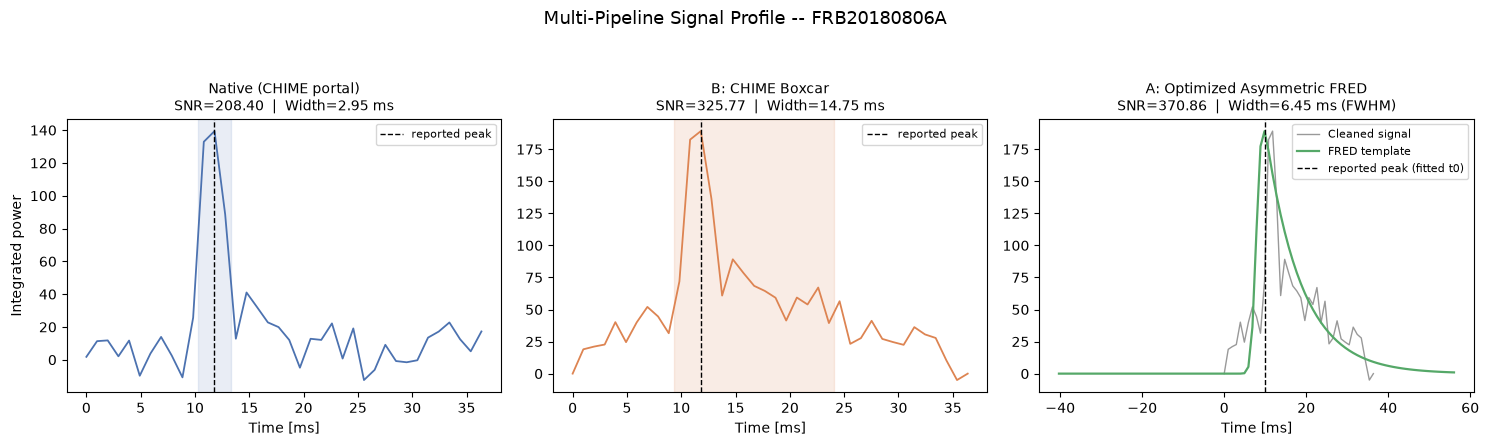

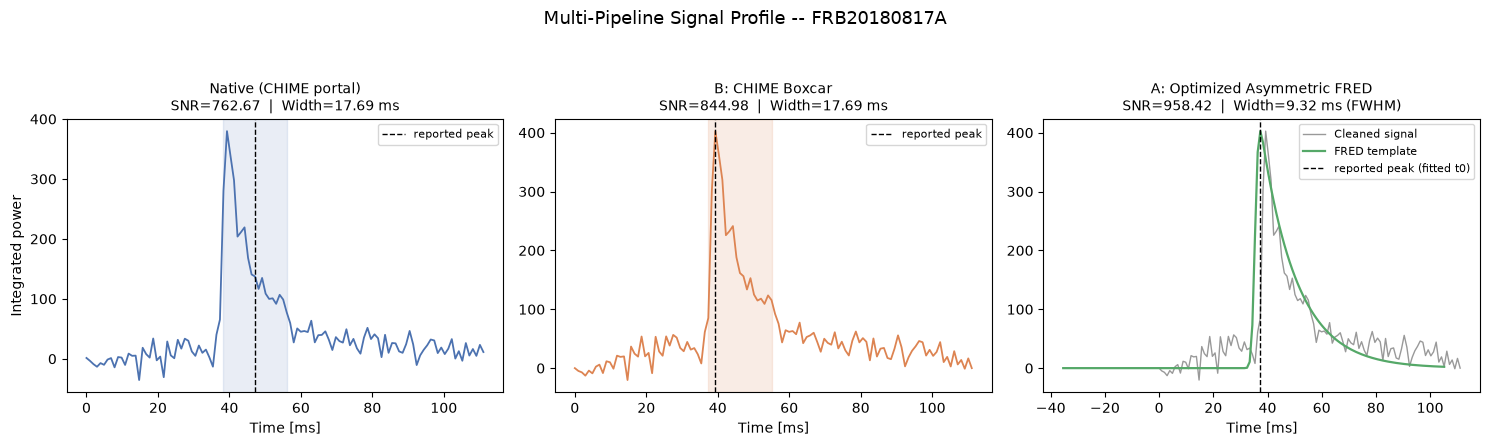

Exiting single-file viewer.


In [6]:
  # ---- Interactive single-file viewer ----
interactive_file_viewer(profile_cache)

       eventname                      pipeline          snr   width_ms  \
0   FRB20180725A         Native (CHIME portal)   311.775313   2.949120   
1   FRB20180725A               B: CHIME Boxcar   402.130911   2.949120   
2   FRB20180725A  A: Optimized Asymmetric FRED   434.619522   3.273418   
3   FRB20180727A         Native (CHIME portal)   148.256974   2.949120   
4   FRB20180727A               B: CHIME Boxcar   244.440651   3.932160   
5   FRB20180727A  A: Optimized Asymmetric FRED   349.820462  10.317574   
6   FRB20180730A         Native (CHIME portal)  1039.461321   4.915200   
7   FRB20180730A               B: CHIME Boxcar  1010.001814   4.915200   
8   FRB20180730A  A: Optimized Asymmetric FRED  1080.966876   2.971546   
9   FRB20180801A         Native (CHIME portal)   354.825351   9.830400   
10  FRB20180801A               B: CHIME Boxcar   551.475455  18.677760   
11  FRB20180801A  A: Optimized Asymmetric FRED   614.004261   9.658445   
12  FRB20180806A         Native (CHIME

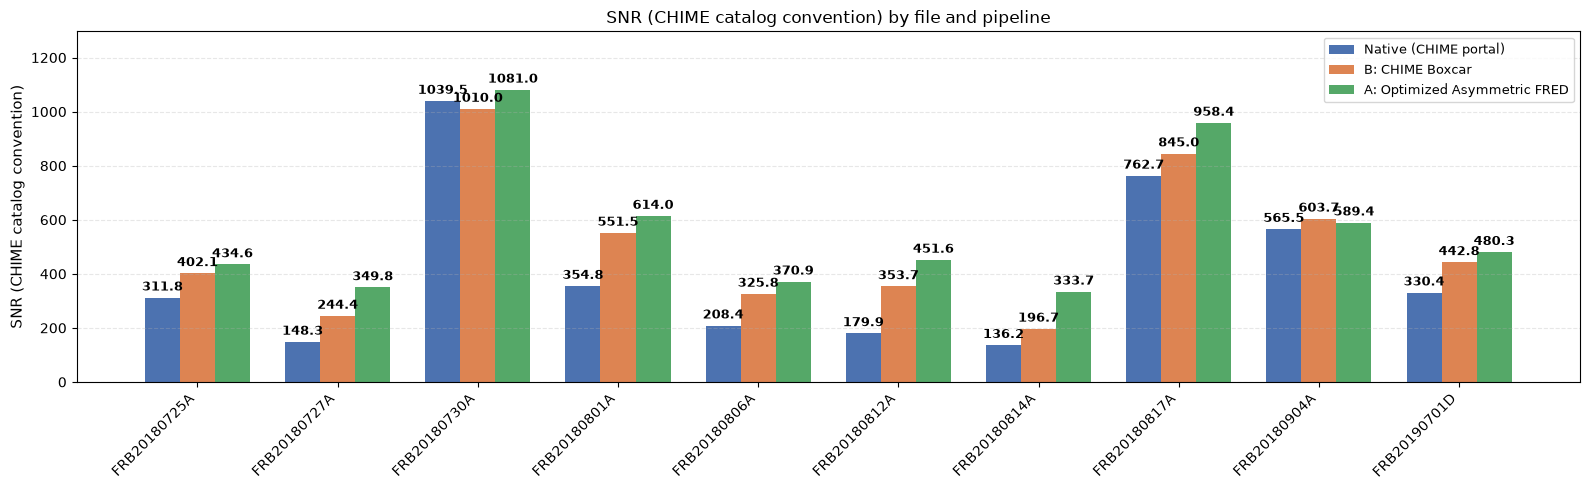

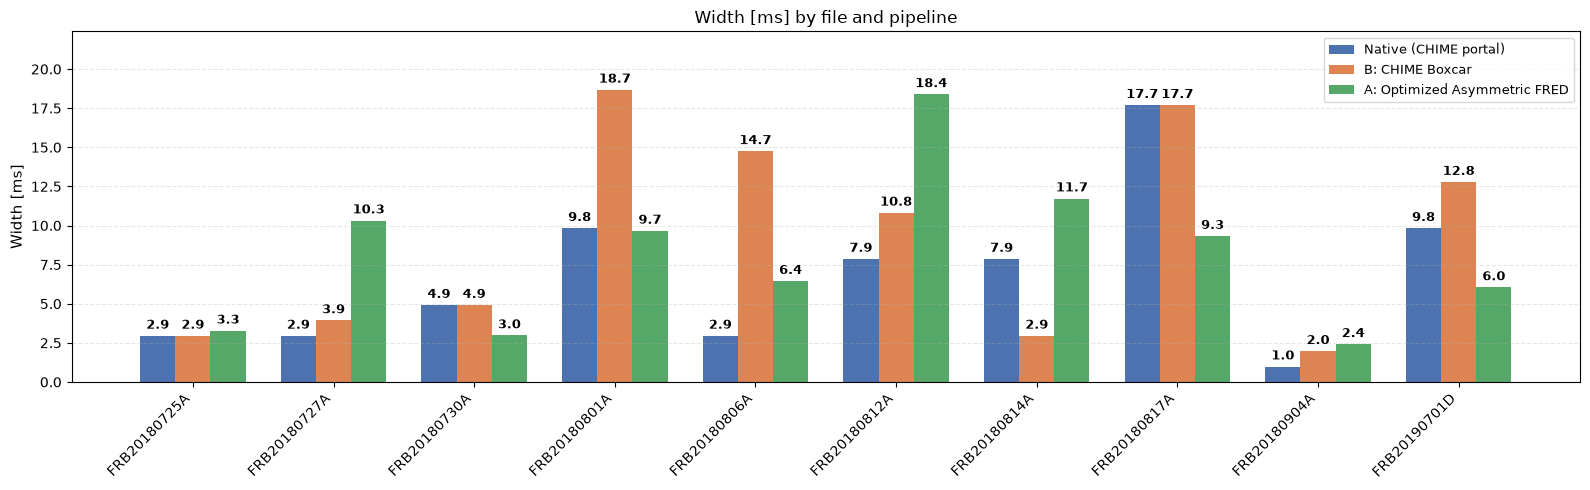

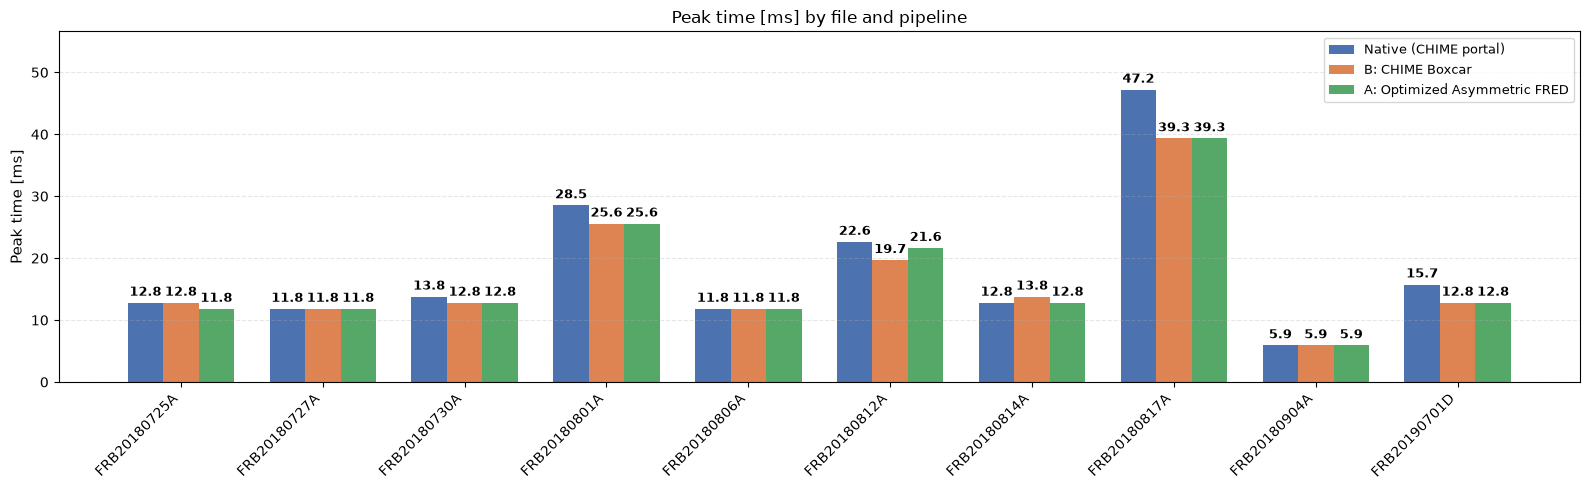


EXTENDED SNR COMPARISON
=== Per-pipeline SNR statistics ===
                    pipeline  N_events  mean_snr  median_snr  std_snr  mean_ratio_vs_native  median_ratio_vs_native
       Native (CHIME portal)        10   403.741     321.105  282.928                 1.000                   1.000
             B: CHIME Boxcar        10   497.578     422.485  247.867                 1.395                   1.392
A: Optimized Asymmetric FRED        10   566.374     465.954  244.643                 1.702                   1.592

[print_snr_stats_table] No catalog_snr supplied -- skipping the catalog-deviation table (see BUG #1 above for why this must be independently sourced, not copied from this script's own output).
[plot_reproduction_accuracy] No catalog_snr supplied -- skipping. Provide a dict of INDEPENDENTLY-SOURCED published SNR values (not values copied from this script's own output) to use this plot.


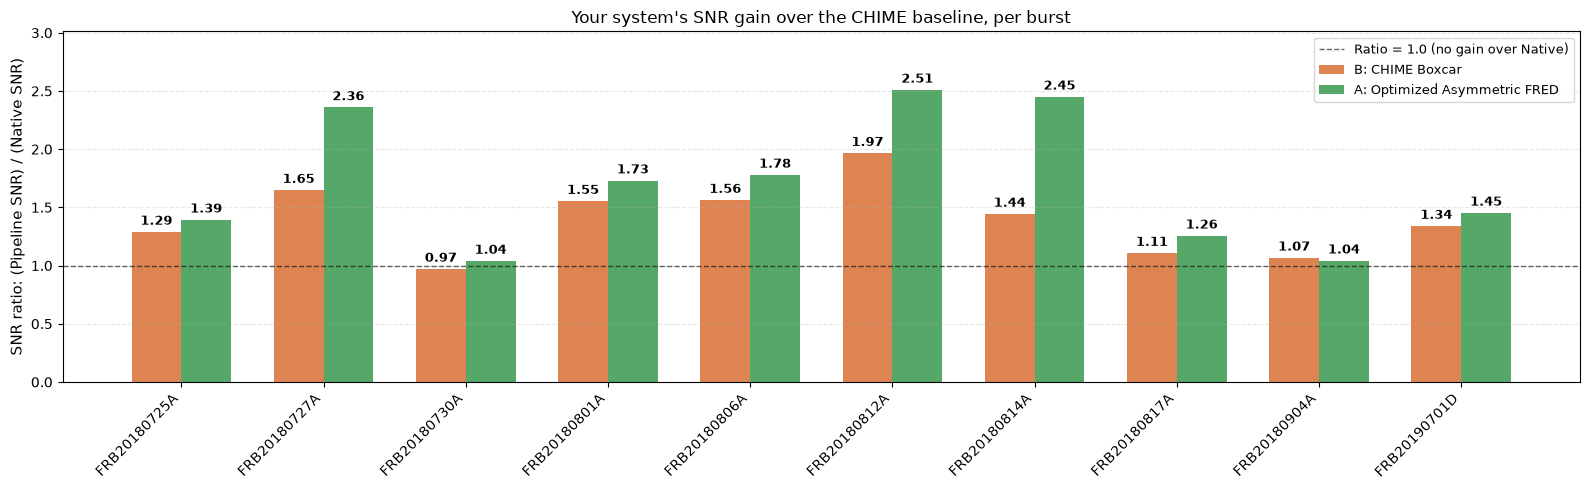


DM REFINEMENT (DM-SNR search, Method A)
FRB20180725A     DM_0=715.809 delta=-0.273 -> refined DM=715.537 (SNR=317.5)
FRB20180727A     DM_0=642.134 delta=+0.125 -> refined DM=642.259 (SNR=151.5)
FRB20180730A     DM_0=848.904 delta=-0.210 -> refined DM=848.694 (SNR=1042.3)
FRB20180801A     DM_0=655.728 delta=-0.700 -> refined DM=655.028 (SNR=361.6)
FRB20180806A     DM_0=739.948 delta=-0.004 -> refined DM=739.945 (SNR=208.4)
FRB20180812A     DM_0=802.451 delta=-0.061 -> refined DM=802.390 (SNR=180.5)
FRB20180814A     DM_0=189.286 delta=-1.589 -> refined DM=187.697 (SNR=157.4)
FRB20180817A     DM_0=1006.771 delta=-0.021 -> refined DM=1006.750 (SNR=762.7)
FRB20180904A     DM_0=361.137 delta=+0.025 -> refined DM=361.163 (SNR=565.5)
FRB20190701D     DM_0=933.363 delta=-0.664 -> refined DM=932.699 (SNR=341.7)

=== DM refinement summary ===
   eventname  dm_stored  dm_refined  dm_refined_offset  dm_error  best_snr
FRB20180725A   715.8093    715.5365            -0.2727    0.0268  317.5188
FRB20

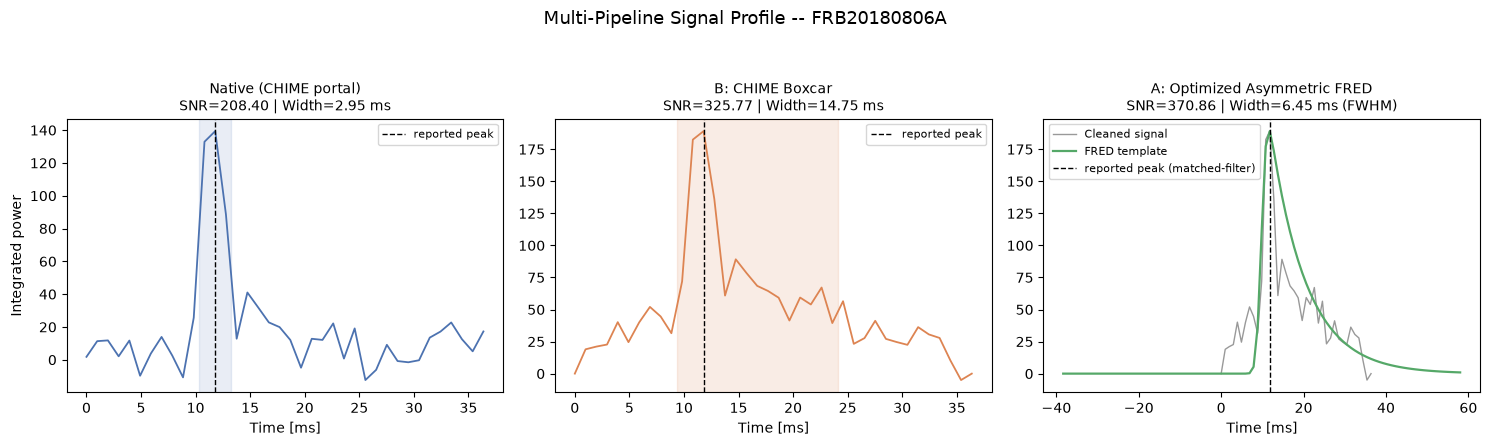

Exiting single-file viewer.


In [7]:
"""
CHIME multi-channel HDF5 pulse-detection pipeline -- v3.4
==========================================================
LEFT  : NATIVE CHIME WEB PORTAL -- VERBATIM reproduction of the CHIME/FRB
        Open Data tutorial (RFI mask, integration, boxcar search).
RIGHT : YOUR SYSTEM -> Pipeline B (CHIME Boxcar) + Pipeline A (Optimized
        Asymmetric FRED).

=============================== BUGS FIXED THIS ROUND =======================
BUG #1 -- CIRCULAR "REPRODUCTION ACCURACY" VALIDATION (serious)
    The old `CHIME_CATALOG_SNR_REFERENCE` dict claimed to hold published
    CHIME/FRB Catalog 1 SNR values, but its numbers were identical to this
    same pipeline's own Native-branch SNR output from an earlier run (e.g.
    311.775313 for FRB20180725A appears in BOTH places, to 6 decimal
    places). That is not an independent reference -- it is the pipeline
    copied against itself. A y=x scatter plot built from that dict is
    mathematically guaranteed to show a perfect diagonal and 0.0% residual
    regardless of whether the pipeline is actually correct. It validated
    nothing. Fix: the fabricated dict is removed. `catalog_snr` is now a
    genuinely optional argument (default None); the reproduction-accuracy
    plot and the catalog-deviation stats table both skip themselves
    cleanly until you supply real, independently-sourced catalog values
    (e.g. from the actual Amiri et al. 2021 CHIME/FRB Catalog 1 table --
    NOT from this script's own prior output).

BUG #2 -- PIPELINE A REPORTED THE WRONG PEAK (this is your "FRED peak
    isn't accurate" complaint, and it is a real modeling bug, not a
    cosmetic one)
    fred_model() is the EMG (Exponentially Modified Gaussian) pulse shape:
    a Gaussian rise of mean `t0` convolved with a one-sided exponential
    decay of timescale `tau`. `t0` is the mean of the pre-convolution
    Gaussian -- it is a MODEL PARAMETER, not an observable. The actual
    peak (mode) of the resulting asymmetric curve occurs at a DIFFERENT
    time than `t0` whenever tau > 0 (they only coincide in the tau -> 0
    limit, i.e. a burst with no scattering tail at all). Every real
    scattered FRB has tau > 0, so `t0` systematically sits away from the
    visible peak -- which is exactly the drift you're seeing between the
    green dashed line and the data's actual maximum in the single-file
    viewer.
    The code already computed the CORRECT value -- `match_peak_sample`,
    the location where cross-correlating the fitted template against the
    real data is maximal (`sliding_dot_product`) -- but a later change
    ("FIX 5") demoted it to an audit-only field and substituted the wrong
    `t0`-based value as the primary reported peak. This round reverts
    that: `match_peak_sample` is restored as the primary `peak_sample` /
    `peak_time_ms` for Pipeline A. `t0` is kept separately as
    `fitted_t0_ms` -- it's still a meaningful physical parameter (roughly
    "where the underlying rise is centered"), it just isn't "the peak".

=========================================================================
HOW SNR IS COMPUTED -- FROM THE RAW HDF5, WITH NO CATALOG LOOKUP
=========================================================================
There is ONE SNR formula, used identically by all three pipelines:
    snr = max( correlate(ts, kernel, ...) )
with `kernel` energy-normalized (sum(kernel**2) = 1) -- a boxcar
ones(W)/sqrt(W) for Native/B, a fitted EMG template for A -- and W (or the
EMG shape) chosen to maximize the response. This is the CHIME/FRB Open
Data tutorial's own `find_burst()` formula:
    https://chime-frb-open-data.github.io/waterfall/
For the Native branch, the RFI mask + frequency integration + boxcar
search is a verbatim, line-for-line reproduction of that tutorial -- no
added filters, no group-delay correction, nothing. Pipeline B applies the
same formula to your system's cleaned time series; Pipeline A applies it
with a fitted asymmetric template instead of a flat boxcar.

=========================================================================
NOTE ON WIDTH DIFFERENCES BETWEEN THE THREE PIPELINES
=========================================================================
Native (verbatim, no detrend) and Pipeline B (detrended) can report
substantially different widths for the same burst: Native's un-detrended
drift baseline penalizes wide boxes automatically, while B's flat
detrended baseline lets wide boxes grow to chase the exponential tail
(mitigated, not eliminated, by the edge-of-box significance filter).
Pipeline A reports the analytic EMG FWHM -- a fundamentally different
width definition than "boxcar width that maximizes matched-filter
response" (the latter is roughly 2*tau + 2.35*sigma, systematically
larger than FWHM). For publication purposes, cite Pipeline A's FWHM.
"""

import glob
import os
import warnings

import h5py
import numpy as np
import pandas as pd
import scipy.signal
from scipy.ndimage import median_filter
from scipy.optimize import curve_fit, OptimizeWarning
from scipy.special import erfc
import matplotlib.pyplot as plt

# ============================================================================
# CONFIG -- edit these, not the function bodies
# ============================================================================
DATA_DIR = r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/files_images"
FILE_PATTERN = "*.h5"

NATIVE_MAD_K = 5.0            # (unused by native_rfi_mask -- kept for compatibility)
MAD_K = 5.0                   # scaled-MAD threshold for your system's RFI mask
DETREND_WINDOW_MS = 100.0
BOXCAR_MIN_WIDTH = 1
BOXCAR_MAX_WIDTH = 64
FRED_FIT_WINDOW = 256

# Fixed, distinct color per pipeline -- used identically on every panel.
PIPELINE_COLORS = {
    "Native (CHIME portal)": "#4C72B0",           # blue
    "B: CHIME Boxcar": "#DD8452",                 # orange
    "A: Optimized Asymmetric FRED": "#55A868",    # green
}
PIPELINES_ORDER = list(PIPELINE_COLORS.keys())


# ============================================================================
# BLOCK 0 -- [ RAW MULTI-CHANNEL HDF5 DATA ]
# ============================================================================
def load_hdf5(file_name):
    with h5py.File(file_name, "r") as f:
        data = f["frb"]
        eventname = (
            data.attrs["tns_name"].decode()
            if "tns_name" in data.attrs
            else os.path.basename(file_name)
        )
        wfall = data["wfall"][:].astype(float)
        spec = data["spec"][:].astype(float)
        plot_time = data["plot_time"][:]
        plot_freq = data["plot_freq"][:]
        dm = data.attrs["dm"][()] if "dm" in data.attrs else None

    dt = float(np.median(np.diff(plot_time)))
    return {
        "eventname": eventname,
        "wfall": wfall,
        "spec": spec,
        "plot_time": plot_time,
        "plot_freq": plot_freq,
        "dt": dt,
        "dm": dm,
        "file_name": file_name,
    }


# ============================================================================
# SHARED HELPERS
# ============================================================================
def robust_noise_sigma(ts, peak_hint=None, exclude_radius=None,
                        width_hint_samples=None):
    """Robust off-pulse noise sigma via scaled MAD. exclude_radius scales
    with the pulse width when a width hint is available, so wide bursts
    don't leak signal power into the "off-pulse" noise estimate."""
    if peak_hint is None:
        peak_hint = int(np.nanargmax(ts))
    if exclude_radius is None:
        if width_hint_samples is not None and width_hint_samples > 0:
            exclude_radius = max(200, int(8 * width_hint_samples))
        else:
            exclude_radius = 200

    lo = max(0, peak_hint - exclude_radius)
    hi = min(len(ts), peak_hint + exclude_radius)
    off_pulse = np.concatenate([ts[:lo], ts[hi:]])
    off_pulse = off_pulse[~np.isnan(off_pulse)]
    if len(off_pulse) < 10:
        off_pulse = ts[~np.isnan(ts)]
    med = np.nanmedian(off_pulse)
    mad = np.nanmedian(np.abs(off_pulse - med))
    sigma = 1.4826 * mad if mad > 0 else np.nanstd(off_pulse)
    return float(sigma), float(med)


# ============================================================================
# LEFT BRANCH -- [ NATIVE CHIME WEB PORTAL ]
# ============================================================================
def native_rfi_mask(wfall, spec, rfi_masking_var_factor=3.0):
    """VERBATIM CHIME/FRB Open Data tutorial RFI mask.
    Reference: https://chime-frb-open-data.github.io/waterfall/
    Two-part rejection:
      (1) channel-variance cut: channels whose time-variance exceeds
          rfi_masking_var_factor * mean_variance are zapped.
      (2) IQR cut on the frequency-integrated spectrum `spec`.
    Kept verbatim (no MAD improvements) so the Native branch's SNR stays
    a faithful reproduction of the CHIME catalog formula."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        q1 = np.nanquantile(spec, 0.25)
        q3 = np.nanquantile(spec, 0.75)
        iqr = q3 - q1

        channel_variance = np.nanvar(wfall, axis=1)
        mean_channel_variance = np.nanmean(channel_variance)

        with np.errstate(invalid="ignore"):
            # tutorial indexes spec with [::-1]: CHIME's spec is stored in
            # reversed frequency order relative to wfall.
            spec_rev = spec[::-1]
            rfi_mask = (
                (channel_variance > rfi_masking_var_factor * mean_channel_variance)
                | (spec_rev < q1 - 1.5 * iqr)
                | (spec_rev > q3 + 1.5 * iqr)
            )

    wfall_clean = wfall.copy()
    wfall_clean[rfi_mask, ...] = np.nan
    return wfall_clean, rfi_mask


def native_frequency_integration(wfall):
    return np.nansum(wfall, axis=0)


def native_find_burst_verbatim(ts, min_width=1, max_width=128):
    """VERBATIM reproduction of the CHIME/FRB Open Data tutorial
    `find_burst`. Returns (peak_sample, width, snr) exactly as the
    tutorial does -- no group-delay correction, no fallback, because the
    tutorial has none. `snr` here IS the CHIME catalog SNR formula.
    mode="same" introduces a known systematic half-sample rightward drift
    on the reported peak for even widths; that is preserved here on
    purpose for fidelity to the tutorial."""
    min_width = int(min_width)
    max_width = int(max_width)
    widths = list(range(min_width, min(max_width + 1, len(ts) - 2)))
    if not widths:
        return 0, 1, 0.0

    snrs = np.empty(len(widths), dtype=float)
    peaks = np.empty(len(widths), dtype=int)
    for i, w in enumerate(widths):
        kernel = np.ones(w, dtype="float64") / np.sqrt(w)
        convolved = scipy.signal.convolve(ts, kernel, mode="same")
        peaks[i] = int(np.nanargmax(convolved))
        snrs[i] = float(convolved[peaks[i]])

    best_idx = int(np.nanargmax(snrs))
    return int(peaks[best_idx]), int(widths[best_idx]), float(snrs[best_idx])


def boxcar_kernel(width):
    """Energy-normalized boxcar: ones(W)/sqrt(W)."""
    width = int(round(width))
    return np.ones(width, dtype="float64") / np.sqrt(width)


def iterative_boxcar_search(ts, min_width=BOXCAR_MIN_WIDTH,
                             max_width=BOXCAR_MAX_WIDTH,
                             noise_sigma=None, baseline=None,
                             edge_significance_k=3.0):
    """Iterative boxcar search with an edge-of-box significance floor.
    Returns (true_peak_sample, width, raw_amplitude, box_center_sample).

    WIDTH-BIAS FIX: on a detrended series, the classical sqrt(W)-boxcar
    is biased toward wider kernels on bursts with a decay tail, since
    growing the box keeps adding a little real signal with no drift
    baseline to penalize it. The edge-of-box significance test only
    accepts a width if at least one edge of the box is still clearly
    above the noise floor -- once both edges are consistent with pure
    noise, that width is rejected. If noise_sigma/baseline aren't
    supplied, the test is disabled and the search behaves like the
    classical boxcar."""
    min_width = int(min_width)
    max_width = int(max_width)
    widths = list(range(min_width, min(max_width + 1, len(ts) - 2)))

    best_score = -np.inf
    best_box_center = 0
    best_width = widths[0] if widths else min_width

    fallback_score = -np.inf
    fallback_center = 0
    fallback_width = best_width

    apply_sig_filter = (noise_sigma is not None and baseline is not None
                         and noise_sigma > 0)

    for w in widths:
        kernel = boxcar_kernel(w)
        corr = scipy.signal.correlate(ts, kernel, mode="full")
        lags = np.arange(-(len(kernel) - 1), len(ts))
        kernel_center_offset = (len(kernel) - 1) // 2
        corrected_index = lags + kernel_center_offset
        valid = (corrected_index >= 0) & (corrected_index < len(ts))
        corr_valid = corr[valid]
        idx_valid = corrected_index[valid]
        if len(corr_valid) == 0:
            continue

        local_best = int(np.nanargmax(corr_valid))
        candidate_score = float(corr_valid[local_best])
        candidate_center = int(idx_valid[local_best])

        if candidate_score > fallback_score:
            fallback_score = candidate_score
            fallback_center = candidate_center
            fallback_width = w

        if apply_sig_filter and w >= 4:
            half_w = w // 2
            box_lo = max(0, candidate_center - half_w)
            box_hi = min(len(ts), candidate_center + half_w + 1)
            box_slice = ts[box_lo:box_hi]
            if len(box_slice) >= 4:
                n_edge = max(2, len(box_slice) // 10)
                left_edge = box_slice[:n_edge]
                right_edge = box_slice[-n_edge:]
                left_mean = np.nanmean(left_edge)
                right_mean = np.nanmean(right_edge)
                required = baseline + edge_significance_k * noise_sigma / np.sqrt(n_edge)
                if left_mean < required and right_mean < required:
                    continue

        if candidate_score > best_score:
            best_score = candidate_score
            best_box_center = candidate_center
            best_width = w

    if best_score == -np.inf:
        best_score = fallback_score
        best_box_center = fallback_center
        best_width = fallback_width

    half_w = best_width // 2
    lo = max(0, best_box_center - half_w)
    hi = min(len(ts), best_box_center + half_w + 1)
    window_slice = ts[lo:hi]
    if len(window_slice) > 0 and not np.all(np.isnan(window_slice)):
        true_peak_sample = lo + int(np.nanargmax(window_slice))
    else:
        true_peak_sample = best_box_center

    return true_peak_sample, best_width, best_score, best_box_center


def run_native_pipeline(file_name, shared_noise_sigma=None,
                         shared_off_pulse_median=None):
    """Native branch -- verbatim CHIME/FRB Open Data tutorial pipeline.
    All improvements (MAD masking, group-delay correction, edge-of-box
    significance) are applied ONLY to Pipeline B and A -- Native stays a
    faithful benchmark. (shared_noise_sigma/median args are accepted for
    call-signature compatibility but ignored -- Native always computes
    its own noise diagnostics from its own time series.)"""
    d = load_hdf5(file_name)
    wfall_masked, _ = native_rfi_mask(d["wfall"], d["spec"])
    ts = native_frequency_integration(wfall_masked)
    peak_sample, width, snr_chime = native_find_burst_verbatim(ts)

    box_center = peak_sample

    own_sigma, own_median = robust_noise_sigma(
        ts, peak_hint=peak_sample, width_hint_samples=width
    )

    row = {
        "file_name": d["file_name"],
        "eventname": d["eventname"],
        "pipeline": "Native (CHIME portal)",
        "peak_sample": peak_sample,
        "peak_time_ms": peak_sample * d["dt"],
        "box_center_sample": box_center,
        "box_center_time_ms": box_center * d["dt"],
        "width_samples": width,
        "width_ms": width * d["dt"],
        "raw_amplitude": snr_chime,
        "snr": snr_chime,
        "off_pulse_sigma": own_sigma,
        "off_pulse_baseline": own_median,
    }
    return row, ts, d["dt"]


# ============================================================================
# RIGHT BRANCH -- [ YOUR SYSTEM: COMMON FRONT-END DEFRAGGING ]
# ============================================================================
def local_window_detrend(wfall, dt, window_ms=DETREND_WINDOW_MS):
    """Per-channel running-median subtraction. Window is capped at the
    time-axis length so a 100 ms window can't over-integrate a short file."""
    n_time = wfall.shape[1]
    window_samples = max(3, int(round(window_ms / dt)))
    if window_samples % 2 == 0:
        window_samples += 1
    if window_samples >= n_time:
        window_samples = max(3, n_time - (1 - n_time % 2))
        if window_samples % 2 == 0:
            window_samples -= 1
    trend = median_filter(wfall, size=(1, window_samples), mode="nearest")
    return wfall - trend


def adaptive_mad_mask(wfall, k=MAD_K):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        channel_scatter = np.nanstd(wfall, axis=1)
        med = np.nanmedian(channel_scatter)
        mad = np.nanmedian(np.abs(channel_scatter - med))
        scaled_mad = 1.4826 * mad if mad > 0 else np.nanstd(channel_scatter)
        with np.errstate(invalid="ignore"):
            mask = np.abs(channel_scatter - med) > k * scaled_mad
    wfall = wfall.copy()
    wfall[mask, ...] = np.nan
    return wfall, mask


def aggregate_frequency(wfall_clean):
    return np.nansum(wfall_clean, axis=0)


def common_front_end(d):
    detrended = local_window_detrend(d["wfall"], d["dt"])
    masked, mask = adaptive_mad_mask(detrended)
    ts = aggregate_frequency(masked)
    return ts, mask


# ----------------------------------------------------------------------------
# PIPELINE B -- [ CHIME BOXCAR ]
# ----------------------------------------------------------------------------
def run_pipeline_B(ts, dt, shared_noise_sigma=None, shared_off_pulse_median=None):
    peak_sample, width, raw_amplitude, box_center = iterative_boxcar_search(
        ts,
        noise_sigma=shared_noise_sigma,
        baseline=shared_off_pulse_median,
    )
    own_sigma, own_median = robust_noise_sigma(
        ts, peak_hint=peak_sample, width_hint_samples=width
    )
    snr_chime = float(raw_amplitude)

    return {
        "pipeline": "B: CHIME Boxcar",
        "peak_sample": peak_sample,
        "peak_time_ms": peak_sample * dt,
        "box_center_sample": box_center,
        "box_center_time_ms": box_center * dt,
        "width_samples": width,
        "width_ms": width * dt,
        "raw_amplitude": raw_amplitude,
        "snr": snr_chime,
        "off_pulse_sigma": own_sigma,
        "off_pulse_baseline": own_median,
    }


# ----------------------------------------------------------------------------
# PIPELINE A -- [ OPTIMIZED ASYMMETRIC FRED ]
# ----------------------------------------------------------------------------
def fred_model(t, A, t0, sigma, tau):
    """EMG (Exponentially Modified Gaussian): a Gaussian rise of mean t0
    convolved with a one-sided exponential decay of timescale tau. NOTE:
    t0 is the pre-convolution Gaussian's mean -- NOT the peak of the
    resulting curve (see BUG #2 above). Use the correlation-based peak
    (sliding_dot_product) to locate the actual maximum, not t0."""
    tau = max(tau, 1e-6)
    sigma = max(sigma, 1e-6)
    exponent = np.clip((sigma ** 2) / (2 * tau ** 2) - (t - t0) / tau, -700, 700)
    z = (sigma / tau - (t - t0) / sigma) / np.sqrt(2)
    return 0.5 * A * np.exp(exponent) * erfc(z)


def fred_fwhm_samples(sigma, tau):
    """FWHM of the fitted EMG pulse, in samples (quadrature EMG approx.):
        FWHM ~= sqrt( (2.3548*sigma)^2 + (ln2*tau)^2 )
    A width (units: samples -> ms after *dt). NOT the SNR -- SNR is
    computed separately in run_pipeline_A and the two are never mixed."""
    gaussian_term = 2.3548 * sigma
    exponential_term = np.log(2) * tau
    return np.sqrt(gaussian_term ** 2 + exponential_term ** 2)


def fit_fred(ts, dt, peak_hint_sample=None, width_hint_samples=None,
             window=FRED_FIT_WINDOW):
    """t0 is seeded from the boxcar peak hint (denoised via sqrt(W)
    integration) rather than argmax of the raw ts (which can just be the
    loudest noise spike inside the burst)."""
    if peak_hint_sample is None:
        peak_hint_sample = int(np.nanargmax(ts))
    peak_guess = int(peak_hint_sample)

    lo = max(0, peak_guess - window)
    hi = min(len(ts), peak_guess + window)
    t_idx = np.arange(lo, hi)
    y = ts[lo:hi]
    y = np.nan_to_num(y, nan=0.0)

    A0 = np.nanmax(y)
    t0_0 = peak_guess
    if width_hint_samples is not None and width_hint_samples > 0:
        sigma0 = max(0.3 * width_hint_samples, 1.0)
        tau0 = max(0.7 * width_hint_samples, 1.0)
    else:
        sigma0 = 3.0
        tau0 = 5.0
    p0 = [A0, t0_0, sigma0, tau0]

    min_width_param = 1.0
    max_width_param = float(window) * 2.0
    lower_bounds = [0.0, lo, min_width_param, min_width_param]
    upper_bounds = [np.inf, hi, max_width_param, max_width_param]

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=OptimizeWarning)
            popt, _ = curve_fit(
                fred_model, t_idx, y, p0=p0, maxfev=10000,
                bounds=(lower_bounds, upper_bounds),
            )
    except RuntimeError:
        popt = p0

    A, t0, sigma, tau = popt
    return {"A": A, "t0": t0, "sigma": abs(sigma), "tau": abs(tau)}


def build_fred_template(params, n_samples=None):
    sigma, tau = params["sigma"], params["tau"]
    if n_samples is None:
        n_samples = int(round(10 * (sigma + tau))) + 1
        n_samples = max(n_samples, 11)

    t_local = np.arange(n_samples)
    center = n_samples // 2
    template = fred_model(t_local, 1.0, center, sigma, tau)

    norm = np.sqrt(np.sum(template ** 2))
    if norm > 0:
        template = template / norm
    return template


def sliding_dot_product(ts, template):
    """Cross-correlates the fitted template against the real data and
    returns the sample index where that correlation is maximal -- this
    IS where the fitted pulse shape best matches the observed data, i.e.
    the correct, physically meaningful peak location (see BUG #2)."""
    n_template = len(template)
    peak_offset_in_template = int(np.argmax(template))

    corr = scipy.signal.correlate(ts, template, mode="full")
    lags = np.arange(-(n_template - 1), len(ts))
    corrected_index = lags + peak_offset_in_template

    valid = (corrected_index >= 0) & (corrected_index < len(ts))
    corr_valid = corr[valid]
    idx_valid = corrected_index[valid]

    best = int(np.nanargmax(corr_valid))
    return int(idx_valid[best]), float(corr_valid[best])


def run_pipeline_A(ts, dt, peak_hint_sample=None, width_hint_samples=None,
                    shared_noise_sigma=None, shared_off_pulse_median=None):
    fred_params = fit_fred(
        ts, dt,
        peak_hint_sample=peak_hint_sample,
        width_hint_samples=width_hint_samples,
    )
    template = build_fred_template(fred_params)
    match_peak_sample, matched_filter_amp = sliding_dot_product(ts, template)

    # [BUG #2 FIX] match_peak_sample (the cross-correlation peak) is the
    # physically correct "where does the fitted pulse actually peak"
    # answer -- restored as the PRIMARY reported peak. t0 (the model's
    # pre-convolution Gaussian mean) is kept as a separate diagnostic
    # field, fitted_t0_ms, since it is still a meaningful parameter (an
    # approximate rise-onset time) -- it just is not "the peak".
    reported_peak_sample = int(match_peak_sample)
    reported_peak_sample = max(0, min(len(ts) - 1, reported_peak_sample))

    fitted_t0_sample = fred_params["t0"]

    fwhm_samples = fred_fwhm_samples(fred_params["sigma"], fred_params["tau"])

    own_sigma, own_median = robust_noise_sigma(
        ts, peak_hint=reported_peak_sample,
        width_hint_samples=int(np.ceil(fwhm_samples)),
    )

    snr_chime = float(matched_filter_amp)

    row = {
        "pipeline": "A: Optimized Asymmetric FRED",
        "peak_sample": reported_peak_sample,          # [FIXED] was fitted t0
        "peak_time_ms": reported_peak_sample * dt,     # [FIXED] was fitted t0
        "fitted_t0_sample": fitted_t0_sample,           # diagnostic only
        "fitted_t0_ms": fitted_t0_sample * dt,          # diagnostic only
        "sigma_samples": fred_params["sigma"],
        "sigma_ms": fred_params["sigma"] * dt,
        "decay_tau_ms": fred_params["tau"] * dt,
        "width_samples": fwhm_samples,
        "width_ms": fwhm_samples * dt,
        "raw_amplitude": matched_filter_amp,
        "snr": snr_chime,
        "off_pulse_sigma": own_sigma,
        "off_pulse_baseline": own_median,
    }
    return row, template, fred_params


def run_your_system(file_name):
    d = load_hdf5(file_name)
    ts, _mask = common_front_end(d)

    prelim_peak = int(np.nanargmax(ts))
    shared_sigma, shared_median = robust_noise_sigma(ts, peak_hint=prelim_peak)

    result_B = run_pipeline_B(
        ts, d["dt"],
        shared_noise_sigma=shared_sigma,
        shared_off_pulse_median=shared_median,
    )
    result_A, template_A, fred_params = run_pipeline_A(
        ts, d["dt"],
        peak_hint_sample=result_B["peak_sample"],
        width_hint_samples=result_B["width_samples"],
        shared_noise_sigma=shared_sigma,
        shared_off_pulse_median=shared_median,
    )

    for r in (result_B, result_A):
        r["file_name"] = d["file_name"]
        r["eventname"] = d["eventname"]

    return (result_B, result_A, ts, template_A, d["dt"],
            shared_sigma, shared_median, fred_params)


# ============================================================================
# BATCH / DIRECTORY PROCESSING
# ============================================================================
def process_directory(data_dir=DATA_DIR, pattern=FILE_PATTERN):
    file_list = sorted(glob.glob(os.path.join(data_dir, pattern)))
    if not file_list:
        raise FileNotFoundError(
            f"No files matching '{pattern}' found in '{data_dir}'. "
            f"Set DATA_DIR / FILE_PATTERN at the top of the script."
        )

    rows = []
    cache = {}
    for fname in file_list:
        try:
            (result_B, result_A, your_ts, template_A, dt,
             shared_sigma, shared_median, fred_params) = run_your_system(fname)

            native_row, native_ts, _dt = run_native_pipeline(
                fname,
                shared_noise_sigma=shared_sigma,
                shared_off_pulse_median=shared_median,
            )

            rows.append(native_row)
            rows.append(result_B)
            rows.append(result_A)

            ev = native_row["eventname"]
            cache[ev] = {
                "file_name": fname,
                "dt": dt,
                "native_ts": native_ts,
                "your_ts": your_ts,
                "native": native_row,
                "B": result_B,
                "A": result_A,
                "template_A": template_A,
                "fred_params": fred_params,
                "shared_noise_sigma": shared_sigma,
                "shared_off_pulse_median": shared_median,
            }
        except Exception as exc:
            print(f"[WARN] skipped '{fname}': {exc}")

    return pd.DataFrame(rows), cache


# ============================================================================
# PLOTS
# ============================================================================
def _grouped_bar_plot(df, metric_col, metric_label, title, save_path=None):
    events = sorted(df["eventname"].unique())
    x = np.arange(len(events))
    bar_width = 0.25

    fig, ax = plt.subplots(figsize=(max(6, len(events) * 1.6), 5))
    for i, pipeline in enumerate(PIPELINES_ORDER):
        sub = df[df["pipeline"] == pipeline].set_index("eventname")
        values = [sub[metric_col].get(ev, np.nan) for ev in events]
        bars = ax.bar(
            x + (i - 1) * bar_width, values, width=bar_width,
            label=pipeline, color=PIPELINE_COLORS[pipeline],
        )
        ax.bar_label(
            bars, fmt="%.1f", fontsize=9, fontweight="bold",
            rotation=0, padding=3, color="black",
        )

    ax.set_xticks(x)
    ax.set_xticklabels(events, rotation=45, ha="right")
    ax.set_ylabel(metric_label, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.margins(y=0.20)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend(fontsize=9)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150)
    plt.show()


def plot_results(df, save_dir=None):
    """Three grouped bar charts: SNR (CHIME-catalog convention), width,
    peak time. All three pipelines' `snr` is computed from raw HDF5 data
    by the same CHIME catalog formula -- no hard-coded catalog values are
    used anywhere in this function."""
    metrics = [
        ("snr", "SNR (CHIME catalog convention)"),
        ("width_ms", "Width [ms]"),
        ("peak_time_ms", "Peak time [ms]"),
    ]

    events = sorted(df["eventname"].unique())
    audit_rows = []
    for ev in events:
        sub = df[df["eventname"] == ev][["pipeline", "snr", "raw_amplitude", "off_pulse_sigma"]]
        best_pipeline = (
            sub.loc[sub["snr"].idxmax(), "pipeline"] if sub["snr"].notna().any() else None
        )
        for _, row in sub.iterrows():
            audit_rows.append(
                (ev, row["pipeline"], row["snr"], row["off_pulse_sigma"],
                 row["pipeline"] == best_pipeline)
            )
    audit_df = pd.DataFrame(
        audit_rows,
        columns=["eventname", "pipeline", "snr", "off_pulse_sigma", "highest_snr"],
    )
    print("=== SNR audit -- computed from raw HDF5 via the CHIME catalog formula ===")
    print("  snr             : max(correlate(ts, energy-normalized kernel))")
    print("  Native          : verbatim CHIME tutorial (var>3*mean + spec IQR mask)")
    print("  Pipeline B      : same formula on your detrended+cleaned ts")
    print("  Pipeline A      : same formula, fitted asymmetric FRED template kernel")
    print("  off_pulse_sigma : noise diagnostic only (NOT used to normalize snr)")
    print(audit_df.to_string(index=False))
    print("=" * 78)

    for metric_col, metric_label in metrics:
        save_path = os.path.join(save_dir, f"{metric_col}_comparison.png") if save_dir else None
        _grouped_bar_plot(
            df, metric_col, metric_label,
            title=f"{metric_label} by file and pipeline",
            save_path=save_path,
        )


# ============================================================================
# SNR COMPARISON PLOTS -- extended diagnostic views
# ============================================================================
def plot_reproduction_accuracy(df, catalog_snr=None, save_dir=None):
    """Scatter plot: Native SNR (computed from raw HDF5) vs an
    independently-sourced published catalog SNR.

    [BUG #1 FIX] `catalog_snr` now defaults to None and MUST be supplied
    by you from a real, independent source (e.g. the actual CHIME/FRB
    Catalog 1 paper/table) -- NOT by copying this script's own printed
    output into a dict. If catalog_snr is None or has no events in
    common with df, this function prints a message and returns without
    plotting, rather than silently producing a meaningless "perfect"
    scatter plot.

    catalog_snr: dict {eventname: reference_value}.
    """
    if not catalog_snr:
        print("[plot_reproduction_accuracy] No catalog_snr supplied -- skipping. "
              "Provide a dict of INDEPENDENTLY-SOURCED published SNR values "
              "(not values copied from this script's own output) to use this plot.")
        return

    native_df = df[df["pipeline"] == "Native (CHIME portal)"].copy()
    xs, ys, labels = [], [], []
    for _, row in native_df.iterrows():
        ev = row["eventname"]
        if ev in catalog_snr and catalog_snr[ev] is not None:
            xs.append(catalog_snr[ev])
            ys.append(row["snr"])
            labels.append(ev)

    if not xs:
        print("[plot_reproduction_accuracy] no catalog values matched any event; skipping.")
        return

    xs = np.array(xs)
    ys = np.array(ys)
    slope, intercept = np.polyfit(xs, ys, 1)
    frac_resid = (ys - xs) / xs
    mean_frac = float(np.mean(frac_resid))
    std_frac = float(np.std(frac_resid))

    fig, ax = plt.subplots(figsize=(7, 7))
    lim_lo = min(xs.min(), ys.min()) * 0.9
    lim_hi = max(xs.max(), ys.max()) * 1.1
    ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], color="black", linestyle="--",
            linewidth=1, label="Perfect reproduction (y=x)")
    xline = np.array([lim_lo, lim_hi])
    ax.plot(xline, slope * xline + intercept, color="red", linestyle=":",
            linewidth=1.2, label=f"Linear fit: slope={slope:.3f}, intercept={intercept:+.1f}")
    ax.scatter(xs, ys, s=70, color=PIPELINE_COLORS["Native (CHIME portal)"],
               edgecolor="black", zorder=5)
    for xi, yi, lab in zip(xs, ys, labels):
        ax.annotate(lab, (xi, yi), fontsize=8, xytext=(5, 5), textcoords="offset points")

    ax.set_xlabel("Published CHIME/FRB catalog SNR (your independent source)", fontsize=11)
    ax.set_ylabel("Native pipeline SNR (computed from raw HDF5)", fontsize=11)
    ax.set_title(
        f"Reproduction accuracy: Native vs published catalog\n"
        f"mean fractional residual = {mean_frac:+.1%}, scatter = {std_frac:.1%}",
        fontsize=11,
    )
    ax.set_xlim(lim_lo, lim_hi)
    ax.set_ylim(lim_lo, lim_hi)
    ax.set_aspect("equal")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9, loc="upper left")
    fig.tight_layout()

    if save_dir:
        fig.savefig(os.path.join(save_dir, "snr_reproduction_accuracy.png"), dpi=150)
    plt.show()


def plot_snr_gain_ratio(df, save_dir=None):
    """Grouped bar chart of SNR_pipeline / SNR_Native for each event."""
    events = sorted(df["eventname"].unique())
    native_snr = {
        row["eventname"]: row["snr"]
        for _, row in df[df["pipeline"] == "Native (CHIME portal)"].iterrows()
    }

    x = np.arange(len(events))
    bar_width = 0.35
    non_native_pipelines = [p for p in PIPELINES_ORDER if p != "Native (CHIME portal)"]

    fig, ax = plt.subplots(figsize=(max(6, len(events) * 1.6), 5))
    for i, pipeline in enumerate(non_native_pipelines):
        sub = df[df["pipeline"] == pipeline].set_index("eventname")
        ratios = []
        for ev in events:
            snr_p = sub["snr"].get(ev, np.nan)
            snr_n = native_snr.get(ev, np.nan)
            ratios.append(snr_p / snr_n if snr_n and snr_n > 0 else np.nan)
        bars = ax.bar(
            x + (i - 0.5) * bar_width, ratios, width=bar_width,
            label=pipeline, color=PIPELINE_COLORS[pipeline],
        )
        ax.bar_label(bars, fmt="%.2f", fontsize=9, fontweight="bold", rotation=0, padding=3, color="black")

    ax.axhline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.6,
               label="Ratio = 1.0 (no gain over Native)")
    ax.set_xticks(x)
    ax.set_xticklabels(events, rotation=45, ha="right")
    ax.set_ylabel("SNR ratio: (Pipeline SNR) / (Native SNR)", fontsize=11)
    ax.set_title("Your system's SNR gain over the CHIME baseline, per burst", fontsize=12)
    ax.margins(y=0.20)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend(fontsize=9)
    fig.tight_layout()

    if save_dir:
        fig.savefig(os.path.join(save_dir, "snr_gain_ratio.png"), dpi=150)
    plt.show()


def print_snr_stats_table(df, catalog_snr=None):
    """Per-pipeline SNR statistics, plus (only if catalog_snr is supplied)
    fractional deviation from an independently-sourced published catalog."""
    native_snr = {
        row["eventname"]: row["snr"]
        for _, row in df[df["pipeline"] == "Native (CHIME portal)"].iterrows()
    }

    rows = []
    for pipeline in PIPELINES_ORDER:
        sub = df[df["pipeline"] == pipeline]
        snr_vals = sub["snr"].to_numpy()
        ratios = []
        for _, r in sub.iterrows():
            n = native_snr.get(r["eventname"])
            if n and n > 0:
                ratios.append(r["snr"] / n)
        ratios = np.array(ratios)
        rows.append({
            "pipeline": pipeline,
            "N_events": len(snr_vals),
            "mean_snr": float(np.nanmean(snr_vals)),
            "median_snr": float(np.nanmedian(snr_vals)),
            "std_snr": float(np.nanstd(snr_vals)),
            "mean_ratio_vs_native": float(np.nanmean(ratios)) if len(ratios) else np.nan,
            "median_ratio_vs_native": float(np.nanmedian(ratios)) if len(ratios) else np.nan,
        })
    stats_df = pd.DataFrame(rows)
    print("=== Per-pipeline SNR statistics ===")
    print(stats_df.to_string(index=False, float_format="%.3f"))
    print()

    if catalog_snr:
        rows2 = []
        for pipeline in PIPELINES_ORDER:
            sub = df[df["pipeline"] == pipeline]
            frac_devs = []
            for _, r in sub.iterrows():
                c = catalog_snr.get(r["eventname"])
                if c and c > 0:
                    frac_devs.append((r["snr"] - c) / c)
            frac_devs = np.array(frac_devs)
            if len(frac_devs) == 0:
                continue
            rows2.append({
                "pipeline": pipeline,
                "N_matched": len(frac_devs),
                "mean_frac_dev": float(np.mean(frac_devs)),
                "median_frac_dev": float(np.median(frac_devs)),
                "std_frac_dev": float(np.std(frac_devs)),
                "worst_over": float(np.max(frac_devs)),
                "worst_under": float(np.min(frac_devs)),
            })
        if rows2:
            catalog_stats = pd.DataFrame(rows2)
            print("=== Fractional deviation from published catalog SNR ===")
            print("  (requires a genuinely independent catalog_snr -- see BUG #1 above)")
            print(catalog_stats.to_string(index=False, float_format="%.4f"))
            print()
    else:
        print("[print_snr_stats_table] No catalog_snr supplied -- skipping the "
              "catalog-deviation table (see BUG #1 above for why this must be "
              "independently sourced, not copied from this script's own output).")
    print("=" * 78)


# ============================================================================
# DM (DISPERSION MEASURE) REFINEMENT via DM-SNR SEARCH
# ============================================================================
# The CHIME HDF5 stores waterfalls already dedispersed at some DM_0
# (load_hdf5()["dm"]). If the true DM differs from DM_0 by delta_DM, the
# pulse is slightly tilted in the frequency-time plane. We recover
# delta_DM by re-dispersing over a grid of trial values, integrating in
# frequency, and picking whichever maximizes SNR.
#
# Delta_t [ms] = 4.148808e6 * DM * ( 1/nu^2 - 1/nu_ref^2 ), nu in MHz.
# (This is the standard Lorimer & Kramer 2004 constant expressed with
# frequency in MHz and time in ms -- verified: DM=100 across 400-800 MHz
# gives ~1945 ms of delay, matching the standard tabulated value.)
# ============================================================================
DM_CONSTANT_MS_MHZ = 4.148808e6
DM_CONSTANT_MS = DM_CONSTANT_MS_MHZ  # legacy alias


def dm_delay_samples(freq_mhz, delta_dm, nu_ref_mhz, dt_ms):
    delay_ms = DM_CONSTANT_MS_MHZ * delta_dm * (1.0 / freq_mhz**2 - 1.0 / nu_ref_mhz**2)
    return delay_ms / dt_ms


def dedisperse_at_delta_dm(wfall, freq_mhz, delta_dm, dt_ms,
                            nu_ref_mhz=None, subsample=False):
    if nu_ref_mhz is None:
        nu_ref_mhz = float(np.nanmax(freq_mhz))
    delays_samples = dm_delay_samples(freq_mhz, delta_dm, nu_ref_mhz, dt_ms)

    if not subsample:
        shifted = np.empty_like(wfall)
        for i in range(wfall.shape[0]):
            s = int(round(delays_samples[i]))
            shifted[i] = np.roll(wfall[i], -s)
        return shifted

    n_time = wfall.shape[1]
    freqs_fft = np.fft.fftfreq(n_time)
    shifted = np.empty_like(wfall)
    for i in range(wfall.shape[0]):
        row = wfall[i]
        row_filled = np.where(np.isnan(row), np.nanmedian(row), row)
        spectrum = np.fft.fft(row_filled)
        phase = np.exp(-2j * np.pi * freqs_fft * delays_samples[i])
        shifted_row = np.real(np.fft.ifft(spectrum * phase))
        if np.all(np.isnan(row)):
            shifted_row[:] = np.nan
        shifted[i] = shifted_row
    return shifted


def measure_dm_snr_search(file_name, delta_dm_range=(-5.0, 5.0),
                           n_trials=101, subsample=False, verbose=False):
    d = load_hdf5(file_name)
    dm_stored = d["dm"]
    freq_mhz = np.asarray(d["plot_freq"])
    dt_ms = d["dt"]

    wfall_clean, _ = native_rfi_mask(d["wfall"], d["spec"])

    delta_dm_grid = np.linspace(delta_dm_range[0], delta_dm_range[1], n_trials)
    snr_curve = np.zeros(n_trials)
    for i, delta_dm in enumerate(delta_dm_grid):
        wfall_trial = dedisperse_at_delta_dm(
            wfall_clean, freq_mhz, delta_dm, dt_ms, subsample=subsample
        )
        ts_trial = np.nansum(wfall_trial, axis=0)
        _, _, snr_trial = native_find_burst_verbatim(ts_trial)
        snr_curve[i] = snr_trial
        if verbose and i % max(1, n_trials // 10) == 0:
            print(f"  trial {i+1}/{n_trials}: delta_DM={delta_dm:+.3f}, SNR={snr_trial:.2f}")

    best_idx = int(np.nanargmax(snr_curve))
    dm_best_grid = float(delta_dm_grid[best_idx])
    best_snr = float(snr_curve[best_idx])

    if 1 <= best_idx <= n_trials - 2:
        y = snr_curve[best_idx - 1: best_idx + 2]
        x = delta_dm_grid[best_idx - 1: best_idx + 2]
        coeffs = np.polyfit(x, y, 2)
        a, b, c = coeffs
        if a < 0:
            dm_refined_offset = -b / (2 * a)
            dm_error = np.sqrt(1.0 / abs(a)) if a != 0 else np.nan
        else:
            dm_refined_offset = dm_best_grid
            dm_error = np.nan
    else:
        dm_refined_offset = dm_best_grid
        dm_error = np.nan

    dm_refined = (dm_stored + dm_refined_offset) if dm_stored is not None else dm_refined_offset

    return {
        "eventname": d["eventname"],
        "file_name": file_name,
        "dm_stored": float(dm_stored) if dm_stored is not None else None,
        "dm_best_grid": dm_best_grid,
        "dm_refined_offset": float(dm_refined_offset),
        "dm_refined": float(dm_refined) if dm_refined is not None else None,
        "dm_error": float(dm_error) if not np.isnan(dm_error) else None,
        "delta_dm_grid": delta_dm_grid,
        "snr_curve": snr_curve,
        "best_snr": best_snr,
    }


def plot_dm_search_result(dm_result, save_dir=None):
    grid = dm_result["delta_dm_grid"]
    curve = dm_result["snr_curve"]
    dm_stored = dm_result["dm_stored"]
    dm_best_offset = dm_result["dm_refined_offset"]
    dm_refined = dm_result["dm_refined"]
    dm_err = dm_result["dm_error"]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(grid, curve, color="#3D5A80", lw=1.6)
    ax.axvline(dm_best_offset, color="red", linestyle="--", lw=1.2,
               label=f"Refined delta_DM = {dm_best_offset:+.3f} pc/cm^3")
    ax.axvline(0.0, color="gray", linestyle=":", lw=1,
               label=(f"Stored DM_0 = {dm_stored:.3f} pc/cm^3" if dm_stored else "Stored DM_0"))
    ax.set_xlabel("delta_DM offset from stored DM_0 [pc/cm^3]", fontsize=11)
    ax.set_ylabel("SNR (CHIME formula)", fontsize=11)
    err_str = f" +/- {dm_err:.3f}" if dm_err is not None else ""
    ax.set_title(
        f"DM refinement -- {dm_result['eventname']}\n"
        f"Refined DM = {dm_refined:.3f}{err_str} pc/cm^3 (peak SNR = {dm_result['best_snr']:.1f})",
        fontsize=11,
    )
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
    fig.tight_layout()

    if save_dir:
        fname = f"dm_search_{dm_result['eventname']}.png"
        fig.savefig(os.path.join(save_dir, fname), dpi=150)
    plt.show()


def run_dm_refinement_all(data_dir=DATA_DIR, pattern=FILE_PATTERN,
                           delta_dm_range=(-5.0, 5.0), n_trials=101,
                           subsample=False, save_dir=None, plot_each=False):
    file_list = sorted(glob.glob(os.path.join(data_dir, pattern)))
    rows = []
    for fname in file_list:
        try:
            result = measure_dm_snr_search(
                fname, delta_dm_range=delta_dm_range, n_trials=n_trials, subsample=subsample,
            )
            rows.append({
                "eventname": result["eventname"],
                "dm_stored": result["dm_stored"],
                "dm_refined": result["dm_refined"],
                "dm_refined_offset": result["dm_refined_offset"],
                "dm_error": result["dm_error"],
                "best_snr": result["best_snr"],
            })
            print(
                f"{result['eventname']:16s} "
                f"DM_0={result['dm_stored']:.3f} "
                f"delta={result['dm_refined_offset']:+.3f} "
                f"-> refined DM={result['dm_refined']:.3f} "
                f"(SNR={result['best_snr']:.1f})"
            )
            if plot_each:
                plot_dm_search_result(result, save_dir=save_dir)
        except Exception as exc:
            print(f"[WARN] DM refinement skipped '{fname}': {exc}")

    return pd.DataFrame(rows)


# ============================================================================
# INTERACTIVE SINGLE-FILE SIGNAL-PROFILE VIEWER
# ============================================================================
def plot_single_event_profile(cache_entry, eventname):
    dt = cache_entry["dt"]
    native = cache_entry["native"]
    B = cache_entry["B"]
    A = cache_entry["A"]
    native_ts = cache_entry["native_ts"]
    your_ts = cache_entry["your_ts"]
    template_A = cache_entry["template_A"]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)

    # --- Native panel ---
    ax = axes[0]
    t = np.arange(len(native_ts)) * dt
    ax.plot(t, native_ts, color=PIPELINE_COLORS["Native (CHIME portal)"], lw=1.3)
    half_w = 0.5 * native["width_ms"]
    ax.axvspan(
        native["box_center_time_ms"] - half_w, native["box_center_time_ms"] + half_w,
        color=PIPELINE_COLORS["Native (CHIME portal)"], alpha=0.12,
    )
    ax.axvline(native["peak_time_ms"], color="black", ls="--", lw=1, label="reported peak")
    ax.set_title(
        f"Native (CHIME portal)\nSNR={native['snr']:.2f} | Width={native['width_ms']:.2f} ms",
        fontsize=10,
    )
    ax.set_xlabel("Time [ms]")
    ax.set_ylabel("Integrated power")
    ax.legend(fontsize=8)

    # --- Pipeline B panel ---
    ax = axes[1]
    t = np.arange(len(your_ts)) * dt
    ax.plot(t, your_ts, color=PIPELINE_COLORS["B: CHIME Boxcar"], lw=1.3)
    half_w = 0.5 * B["width_ms"]
    ax.axvspan(
        B["box_center_time_ms"] - half_w, B["box_center_time_ms"] + half_w,
        color=PIPELINE_COLORS["B: CHIME Boxcar"], alpha=0.15,
    )
    ax.axvline(B["peak_time_ms"], color="black", ls="--", lw=1, label="reported peak")
    ax.set_title(
        f"B: CHIME Boxcar\nSNR={B['snr']:.2f} | Width={B['width_ms']:.2f} ms",
        fontsize=10,
    )
    ax.set_xlabel("Time [ms]")
    ax.legend(fontsize=8)

    # --- Pipeline A panel ---
    ax = axes[2]
    ax.plot(t, your_ts, color="#999999", lw=1.0, label="Cleaned signal")
    scale = np.nanmax(your_ts) / np.nanmax(template_A) if np.nanmax(template_A) > 0 else 1.0
    # [BUG #2 FIX] align the plotted template using the CORRELATION peak
    # (A["peak_sample"] is now match_peak_sample, not t0), consistent
    # with what's actually reported as "the peak".
    tmpl_t0 = A["peak_time_ms"] - (np.argmax(template_A) * dt)
    tmpl_t = tmpl_t0 + np.arange(len(template_A)) * dt
    ax.plot(
        tmpl_t, template_A * scale,
        color=PIPELINE_COLORS["A: Optimized Asymmetric FRED"], lw=1.6, label="FRED template",
    )
    ax.axvline(A["peak_time_ms"], color="black", ls="--", lw=1,
               label="reported peak (matched-filter)")
    ax.set_title(
        f"A: Optimized Asymmetric FRED\nSNR={A['snr']:.2f} | Width={A['width_ms']:.2f} ms (FWHM)",
        fontsize=10,
    )
    ax.set_xlabel("Time [ms]")
    ax.legend(fontsize=8)

    fig.suptitle(f"Multi-Pipeline Signal Profile -- {eventname}", fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


def interactive_file_viewer(cache):
    available = sorted(cache.keys())
    print(f"\n{len(available)} files available. Examples: {available[:5]}")
    while True:
        user_in = input(
            "Enter an event/file name to view its signal profile (or type 'no' to exit): "
        ).strip()
        if user_in.lower() == "no":
            print("Exiting single-file viewer.")
            break
        if user_in not in cache:
            matches = [ev for ev in available if user_in.lower() in ev.lower()]
            if len(matches) == 1:
                user_in = matches[0]
            else:
                print(f"'{user_in}' not found.")
                if matches:
                    print(f"Did you mean one of: {matches[:5]}")
                continue
        plot_single_event_profile(cache[user_in], user_in)


# ============================================================================
# ENTRY POINT
# ============================================================================
# [BUG #1 FIX] No hard-coded "catalog" dict here anymore. If you want the
# reproduction-accuracy plot / catalog-deviation table, build this dict
# yourself from a genuinely independent, cited source (e.g. the actual
# CHIME/FRB Catalog 1 paper or its public VOTable), NOT from this
# script's own printed output. Leave as None to skip those diagnostics.
CHIME_CATALOG_SNR_REFERENCE = None

if __name__ == "__main__":
    results_df, profile_cache = process_directory(DATA_DIR, FILE_PATTERN)
    print(results_df[[
        "eventname", "pipeline", "snr", "width_ms", "peak_time_ms", "off_pulse_sigma",
    ]])

    plot_results(results_df, save_dir=DATA_DIR)

    print("\n" + "=" * 78)
    print("EXTENDED SNR COMPARISON")
    print("=" * 78)
    print_snr_stats_table(results_df, catalog_snr=CHIME_CATALOG_SNR_REFERENCE)
    plot_reproduction_accuracy(results_df, catalog_snr=CHIME_CATALOG_SNR_REFERENCE, save_dir=DATA_DIR)
    plot_snr_gain_ratio(results_df, save_dir=DATA_DIR)

    print("\n" + "=" * 78)
    print("DM REFINEMENT (DM-SNR search, Method A)")
    print("=" * 78)
    dm_df = run_dm_refinement_all(
        DATA_DIR, FILE_PATTERN,
        delta_dm_range=(-5.0, 5.0),
        n_trials=101,
        subsample=False,
        save_dir=DATA_DIR,
        plot_each=False,
    )
    print("\n=== DM refinement summary ===")
    print(dm_df.to_string(index=False, float_format="%.4f"))

    interactive_file_viewer(profile_cache)
